<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/master/dengue_bd_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
# ══════════════════════════════════════════════════════════════
# STEP 0 ── Imports & Settings
# ══════════════════════════════════════════════════════════════
import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# sklearn
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate)
from sklearn.ensemble        import (RandomForestClassifier,
                                     StackingClassifier)
from sklearn.tree            import DecisionTreeClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     confusion_matrix, roc_auc_score,
                                     roc_curve, mean_absolute_error,
                                     mean_squared_error)
# imbalanced-learn
from imblearn.combine        import SMOTEENN, SMOTETomek
from imblearn.over_sampling  import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks

# optional
try:
    from lightgbm import LGBMClassifier; _LGB = True
except ImportError:
    _LGB = False; print("pip install lightgbm")

try:
    import shap; _SHAP = True
except ImportError:
    _SHAP = False; print("pip install shap")

try:
    from lime import lime_tabular; _LIME = True
except ImportError:
    _LIME = False; print("pip install lime")

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ── Plot style (paper-quality) ────────────────────────────────
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'savefig.bbox': 'tight'})

# ── Output folder ─────────────────────────────────────────────
OUT = 'paper_outputs'
os.makedirs(OUT, exist_ok=True)

def save(name):
    plt.savefig(f'{OUT}/{name}.png', dpi=150, bbox_inches='tight')
    print(f'  ✓ saved {name}.png')

print("✅ Step 0 complete — all imports OK")

pip install lime
✅ Step 0 complete — all imports OK


In [61]:

from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# STEP 1 ── Load Data
# ══════════════════════════════════════════════════════════════
# ⚠️ Change this path to your CSV location
DATA_PATH = '/content/drive/MyDrive/Dengue Hematology Dataset_bd.csv'
# If running locally:
# DATA_PATH = 'Dengue_Hematology_Dataset_bd.csv'

df_raw = pd.read_csv(DATA_PATH)

# Drop unusable columns (ALT, AST almost entirely missing; Sl. is serial)
df = df_raw.drop(columns=['Sl.', 'ALT', 'AST', 'Unnamed: 12'],
                 errors='ignore').copy()

print(f"✅ Step 1 — Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"   Columns : {df.columns.tolist()}")
print(f"   Target  : {df['Dengue NS1'].value_counts().to_dict()}")
df.head()

✅ Step 1 — Loaded: 1037 rows × 9 cols
   Columns : ['Age (year)', 'Sex', 'Dengue NS1', 'PLT', 'WBC', 'HCT', 'RBC', 'Lymph %', 'Neut %']
   Target  : {'Positive': 805, 'Negative': 232}


,Age (year),Sex,Dengue NS1,PLT,WBC,HCT,RBC,Lymph %,Neut %
0,23.0,Female,Positive,223,3.21,36.6,4.68,28.7,61.7
1,20.0,Female,Positive,93,2.61,35.9,4.41,28.4,66.9
2,1.0,Female,Positive,504,15.06,33.1,5.14,37.5,54.2
3,32.0,Male,Positive,82,5.11,51.5,6.39,47.0,44.9
4,54.0,Male,Positive,171,2.87,34.2,4.09,11.1,76.0


In [63]:
desc = df.describe().T[['count','mean','std','min','25%','50%','75%','max']]
desc.columns = ['N','Mean','SD','Min','Q1','Median','Q3','Max']
desc.round(3)

,N,Mean,SD,Min,Q1,Median,Q3,Max
Age (year),1037.0,29.990,13.857,0.50,22.0,27.000,38.00,80.000
PLT,1037.0,116012.893,102087.308,40.00,38850.0,90000.000,170000.00,482000.000
WBC,1037.0,6496.586,3788.075,1.84,3960.0,5700.000,8180.00,29744.000
HCT,1037.0,41.182,5.762,16.00,37.4,41.300,45.42,57.270
RBC,1037.0,5.122,2.811,2.54,4.5,4.998,5.57,66.912
Lymph %,1037.0,35.089,15.292,3.00,23.0,35.000,45.00,78.540
Neut %,1037.0,58.346,16.518,16.00,46.8,58.240,70.00,97.760


Duplicate rows : 20
Total missing  : 0

Class distribution:
  Positive    :  805  (77.63 %)
  Negative    :  232  (22.37 %)
  ✓ saved fig_01_overview.png


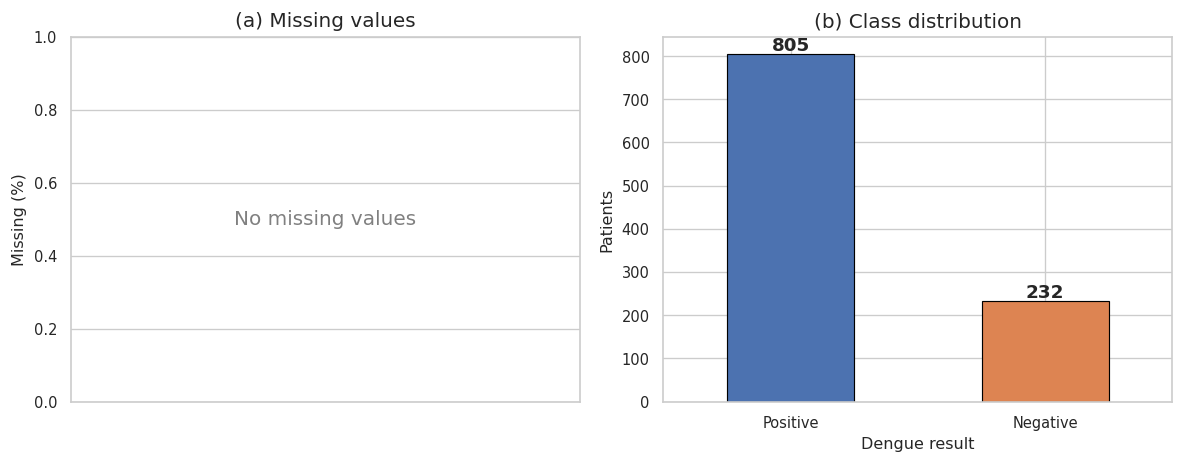

In [64]:
missing_pct = (df.isna().sum() / len(df) * 100).round(3)
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Total missing  : {df.isna().sum().sum()}')

class_counts = df['Dengue NS1'].value_counts()
print('\nClass distribution:')
for c,n in class_counts.items():
    print(f'  {c:<12s}: {n:>4d}  ({n/len(df)*100:5.2f} %)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Missing-values bar
if missing_pct.sum() == 0:
    axes[0].text(.5,.5,'No missing values',ha='center',va='center',
                 transform=axes[0].transAxes,fontsize=12,color='gray')
    axes[0].set_xticks([])
else:
    missing_pct[missing_pct>0].plot(kind='bar',ax=axes[0],
        color='#C44E52',edgecolor='black',linewidth=.6)
axes[0].set_ylabel('Missing (%)'); axes[0].set_title('(a) Missing values')

# Class distribution
colors = ['#4C72B0','#DD8452']
class_counts.plot(kind='bar',ax=axes[1],color=colors,edgecolor='black',linewidth=.7)
for i,v in enumerate(class_counts.values):
    axes[1].text(i, v + max(class_counts)*.01, str(v), ha='center',fontweight='bold')
axes[1].set_xlabel('Dengue result'); axes[1].set_ylabel('Patients')
axes[1].set_title('(b) Class distribution'); axes[1].set_xticklabels(class_counts.index,rotation=0)

plt.tight_layout(); save('fig_01_overview'); plt.show()

  ✓ saved fig_02_correlation_heatmap.png


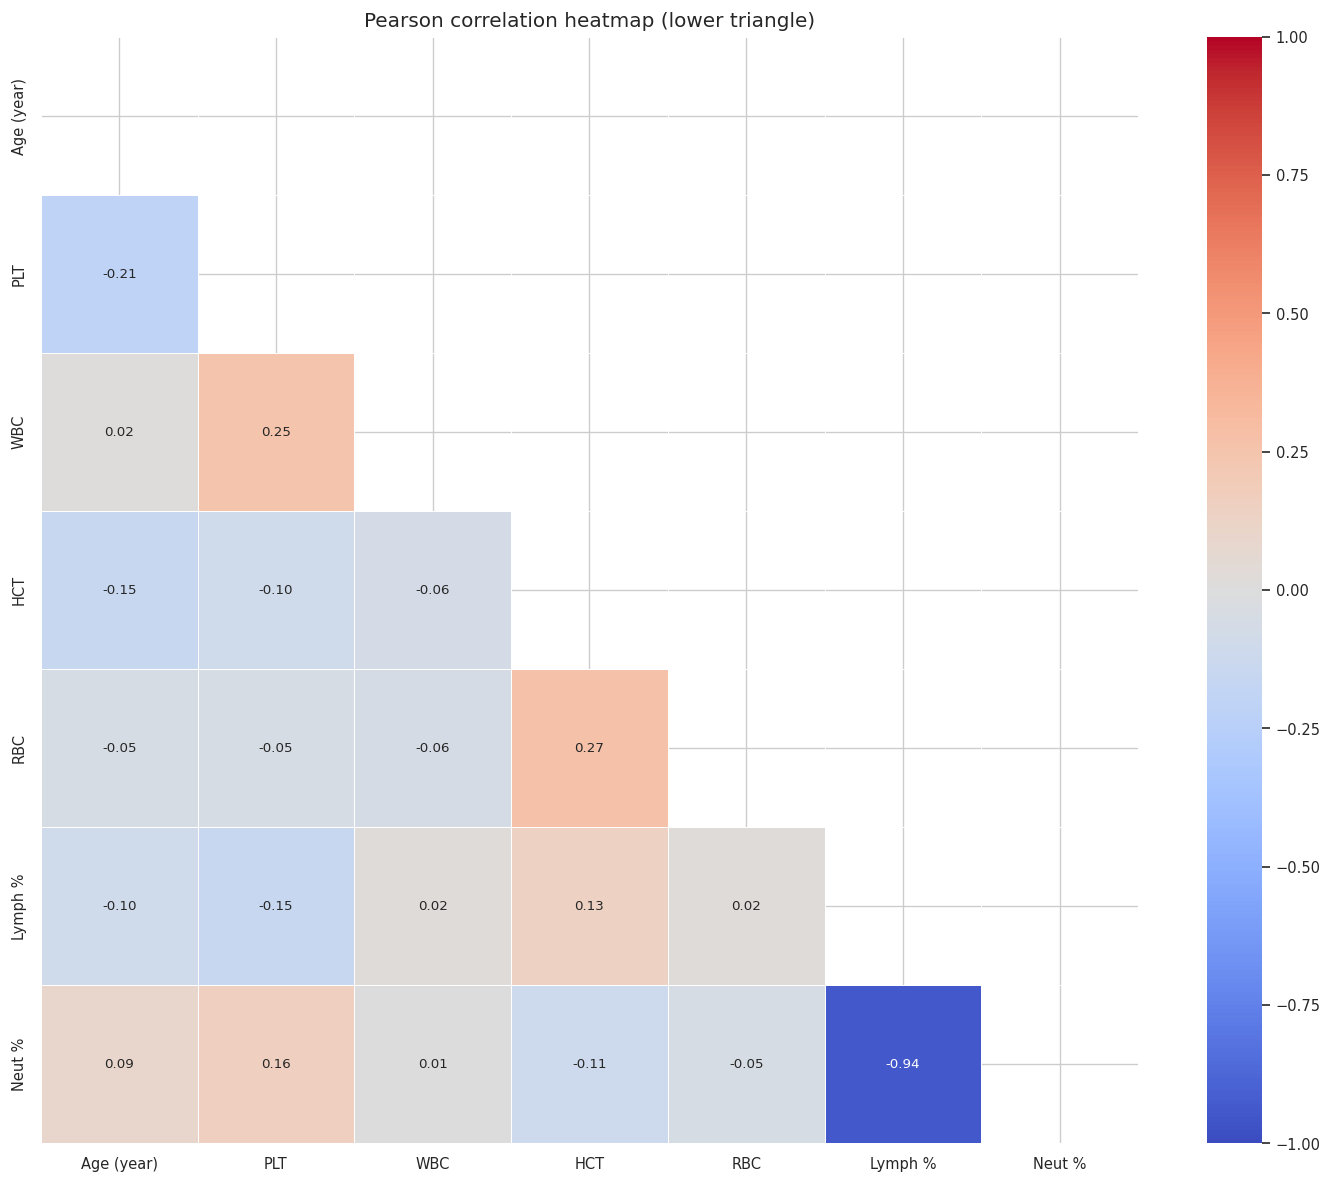

Variance Inflation Factors (VIF > 10 → high multicollinearity):


,Feature,VIF
0,HCT,52.36
1,Neut %,25.97
2,Lymph %,13.88
3,Age (year),6.00
4,RBC,4.69
5,WBC,4.27
6,PLT,2.67


In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Result']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=.5, annot_kws={'size':8}, ax=ax)
ax.set_title('Pearson correlation heatmap (lower triangle)')
plt.tight_layout(); save('fig_02_correlation_heatmap'); plt.show()

# VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = num_cols
vif_data['VIF']     = [variance_inflation_factor(df[num_cols].values, i)
                       for i in range(len(num_cols))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print('Variance Inflation Factors (VIF > 10 \u2192 high multicollinearity):')
vif_data.round(2)

In [66]:
# STEP 2 ── Label Encoding  (paper §3.2.1)
# ══════════════════════════════════════════════════════════════
# Sex  : Male=1, Female=0
# NS1  : Positive=1, Negative=0
df['Sex']        = df['Sex'].map({'Male': 1, 'Female': 0,
                                   'male': 1, 'female': 0})
df['Dengue NS1'] = df['Dengue NS1'].map({'Positive': 1, 'Negative': 0,
                                          'positive': 1, 'negative': 0})
df.rename(columns={'Sex': 'Gender', 'Dengue NS1': 'Result',
                   'Age (year)': 'Age', 'Lymph %': 'Lymphocytes(%)',
                   'Neut %': 'Neutrophils(%)',
                   'PLT': 'Total Platelet Count(/cumm)',
                   'WBC': 'Total WBC count(/cumm)',
                   'HCT': 'HCT(%)'}, inplace=True)

TARGET   = 'Result'
FEATURES = [c for c in df.columns if c != TARGET]

X_all = df[FEATURES].copy()
y_all = df[TARGET].copy()

print(f"\n✅ Step 2 — Label encoding done")
print(f"   Features : {FEATURES}")
print(f"   Class    : Positive={y_all.sum()}  Negative={(y_all==0).sum()}")


✅ Step 2 — Label encoding done
   Features : ['Age', 'Gender', 'Total Platelet Count(/cumm)', 'Total WBC count(/cumm)', 'HCT(%)', 'RBC', 'Lymphocytes(%)', 'Neutrophils(%)']
   Class    : Positive=805  Negative=232



── Fig 2: Population distribution ──
  ✓ saved fig02_population_distribution.png


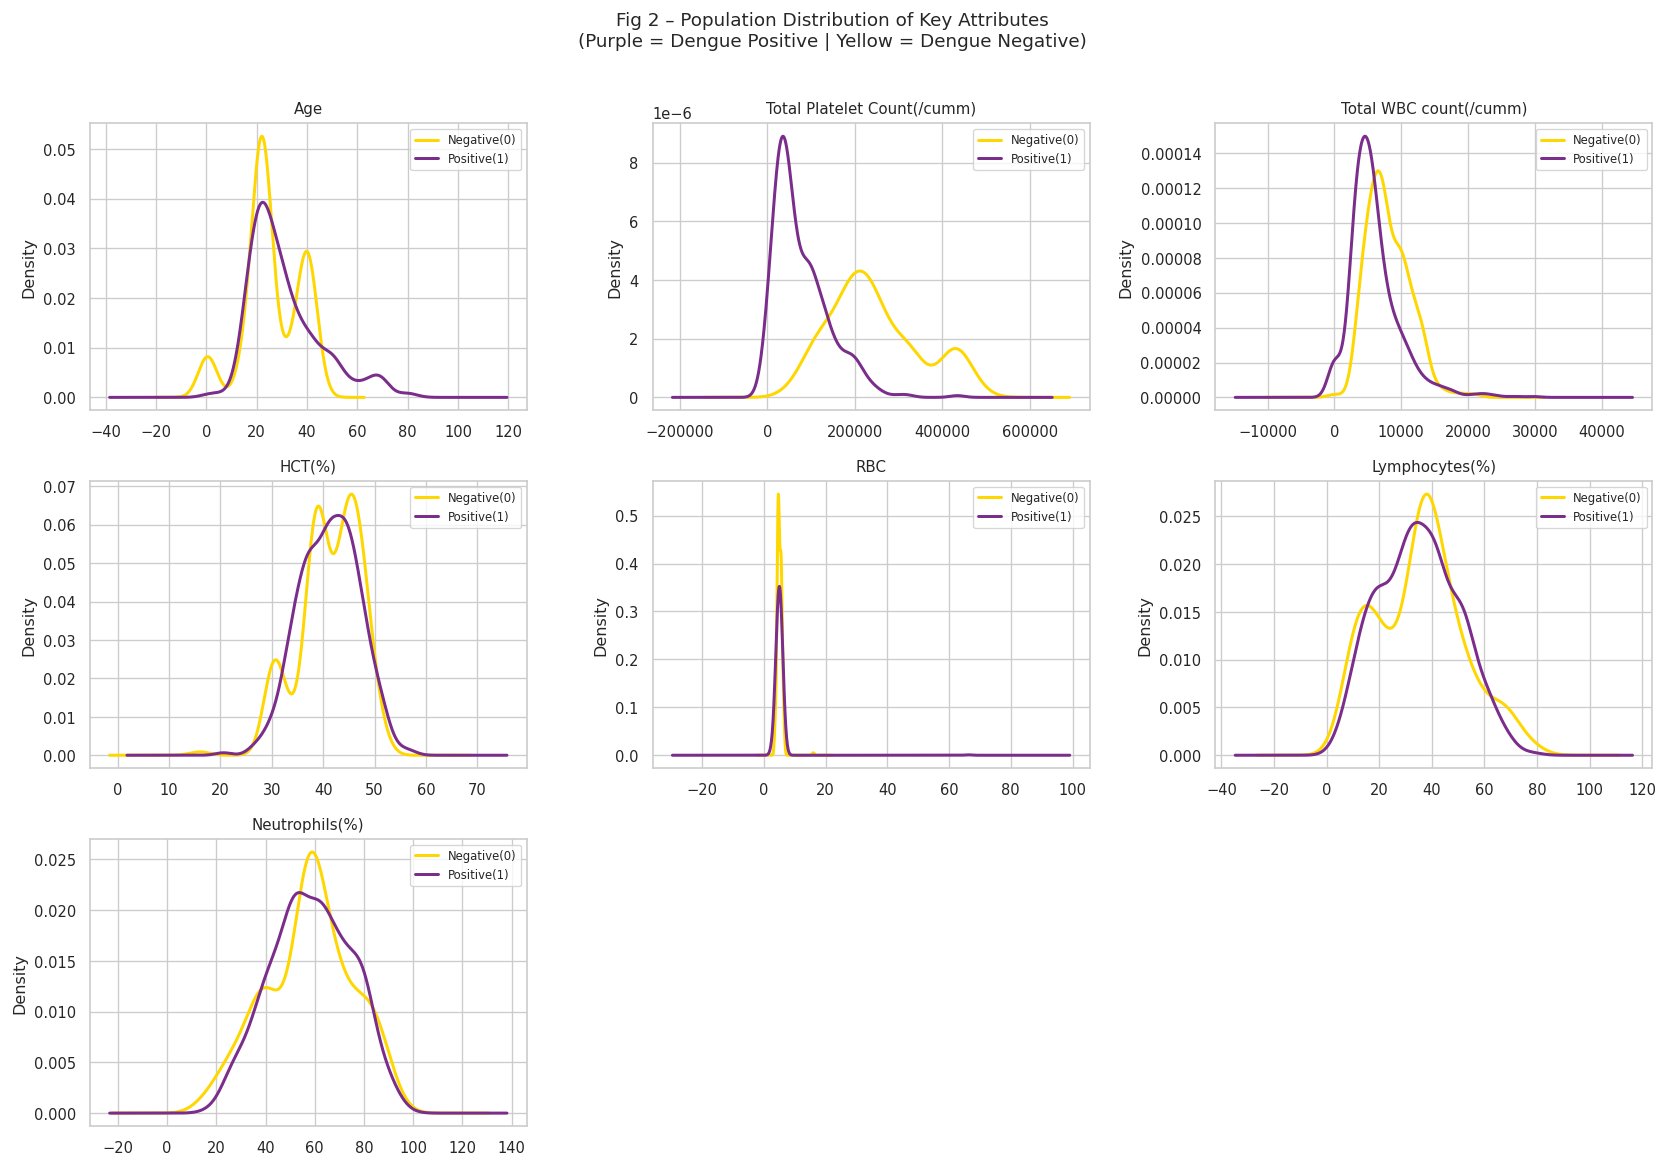

✅ Step 3 complete


In [67]:
# STEP 3 ── Figure 2 : Population Distribution  (paper Fig.2)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 2: Population distribution ──")

num_feats = [f for f in FEATURES if f != 'Gender']
cols = 3
rows = (len(num_feats) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
axes = axes.flatten()

pal = {0: '#FFD700', 1: '#7B2D8B'}  # yellow=negative, purple=positive

for i, feat in enumerate(num_feats):
    ax = axes[i]
    for cls, color in pal.items():
        subset = X_all[y_all == cls][feat].dropna()
        subset.plot.kde(ax=ax, color=color,
                        label='Positive(1)' if cls == 1 else 'Negative(0)',
                        linewidth=1.8)
        ax.fill_between(np.linspace(subset.min(), subset.max(), 200),
                        0, sns.kdeplot(subset, ax=None).get_lines()[0].get_ydata()
                        if False else 0, alpha=0)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Gender bar as last
ax_g = axes[i + 1] if i + 1 < len(axes) else None
if ax_g:
    gd = df.groupby(['Gender', TARGET]).size().unstack(fill_value=0)
    gd.index = ['Female', 'Male']
    gd.columns = ['Negative', 'Positive']
    gd.plot(kind='bar', ax=ax_g, color=['#FFD700', '#7B2D8B'],
            edgecolor='k', linewidth=0.5)
    ax_g.set_title('Gender', fontsize=9)
    ax_g.set_xticklabels(['Female', 'Male'], rotation=0)

plt.suptitle('Fig 2 – Population Distribution of Key Attributes\n'
             '(Purple = Dengue Positive | Yellow = Dengue Negative)',
             fontsize=11, y=1.01)
plt.tight_layout()
save('fig02_population_distribution')
plt.show()
print("✅ Step 3 complete")


── Fig 3: Outliers before removal ──
  ✓ saved fig03_outliers_before.png


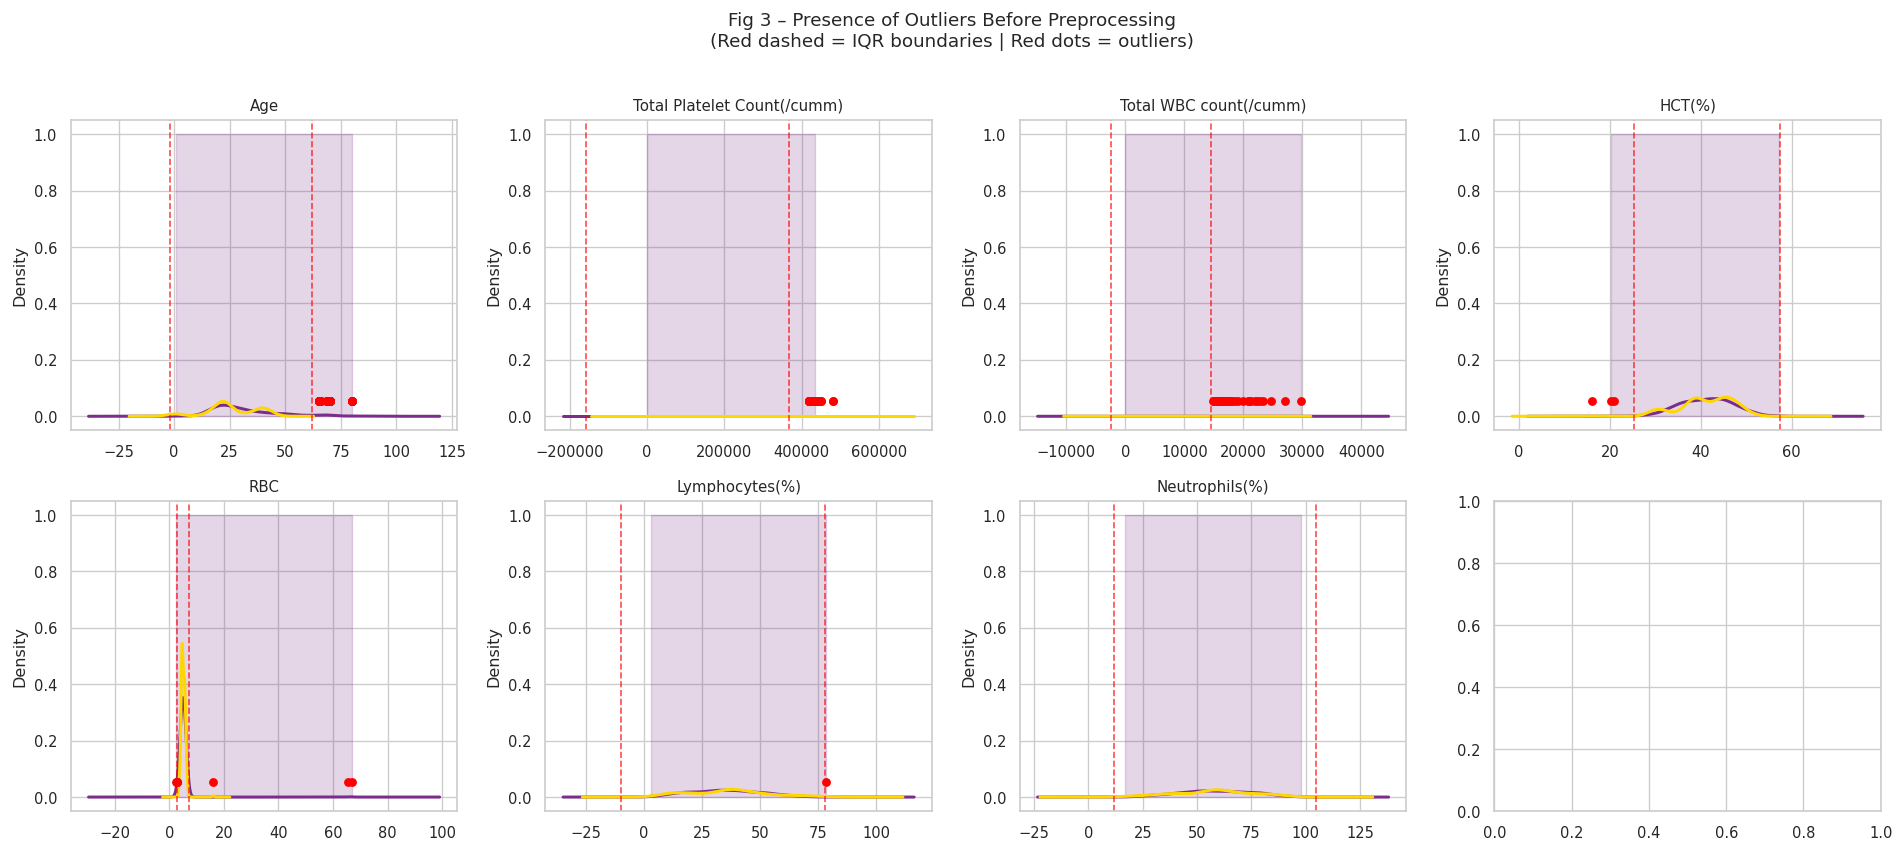

In [68]:
# STEP 4 ── Figure 3 : Outliers BEFORE removal  (paper Fig.3)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 3: Outliers before removal ──")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(num_feats[:8]):
    ax = axes[i]
    data_pos = X_all[y_all == 1][feat].dropna()
    data_neg = X_all[y_all == 0][feat].dropna()
    ax.fill_between(np.linspace(data_pos.min(), data_pos.max(), 100),
                    0, 1, alpha=0.2, color='#7B2D8B')
    try:
        data_pos.plot.kde(ax=ax, color='#7B2D8B', linewidth=1.8)
        data_neg.plot.kde(ax=ax, color='#FFD700', linewidth=1.8)
    except Exception:
        pass
    # mark outliers with IQR
    Q1, Q3 = X_all[feat].quantile(0.25), X_all[feat].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    ax.axvline(lo, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(hi, color='red', linestyle='--', linewidth=1, alpha=0.7)
    outliers = X_all[(X_all[feat] < lo) | (X_all[feat] > hi)][feat]
    ax.scatter(outliers, [ax.get_ylim()[1] * 0.05] * len(outliers),
               color='red', s=20, zorder=5, marker='o')
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Fig 3 – Presence of Outliers Before Preprocessing\n'
             '(Red dashed = IQR boundaries | Red dots = outliers)',
             fontsize=11, y=1.01)
plt.tight_layout()
save('fig03_outliers_before')
plt.show()

In [69]:
# STEP 5 ── Outlier Removal  (paper §3.2.2)
# ══════════════════════════════════════════════════════════════
print("\n── Outlier Removal ──")

def iqr_clean(X, y, cols, factor=1.5):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        Q1, Q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        IQR = Q3 - Q1
        mask &= X[c].between(Q1 - factor*IQR, Q3 + factor*IQR)
    return X[mask].copy(), y[mask].copy()

# Columns that had outliers per paper (equivalent cols in this dataset)
outlier_cols = ['Lymphocytes(%)', 'Neutrophils(%)', 'RBC',
                'HCT(%)', 'Total Platelet Count(/cumm)',
                'Total WBC count(/cumm)']
outlier_cols = [c for c in outlier_cols if c in X_all.columns]

X_clean, y_clean = iqr_clean(X_all, y_all, outlier_cols)
print(f"   Before: {len(X_all)}  →  After: {len(X_clean)} "
      f"(removed {len(X_all)-len(X_clean)})")
print(f"   Class after clean: Pos={y_clean.sum()}  Neg={(y_clean==0).sum()}")


── Outlier Removal ──
   Before: 1037  →  After: 957 (removed 80)
   Class after clean: Pos=766  Neg=191



── Fig 4: After outlier removal ──
  ✓ saved fig04_outliers_after.png


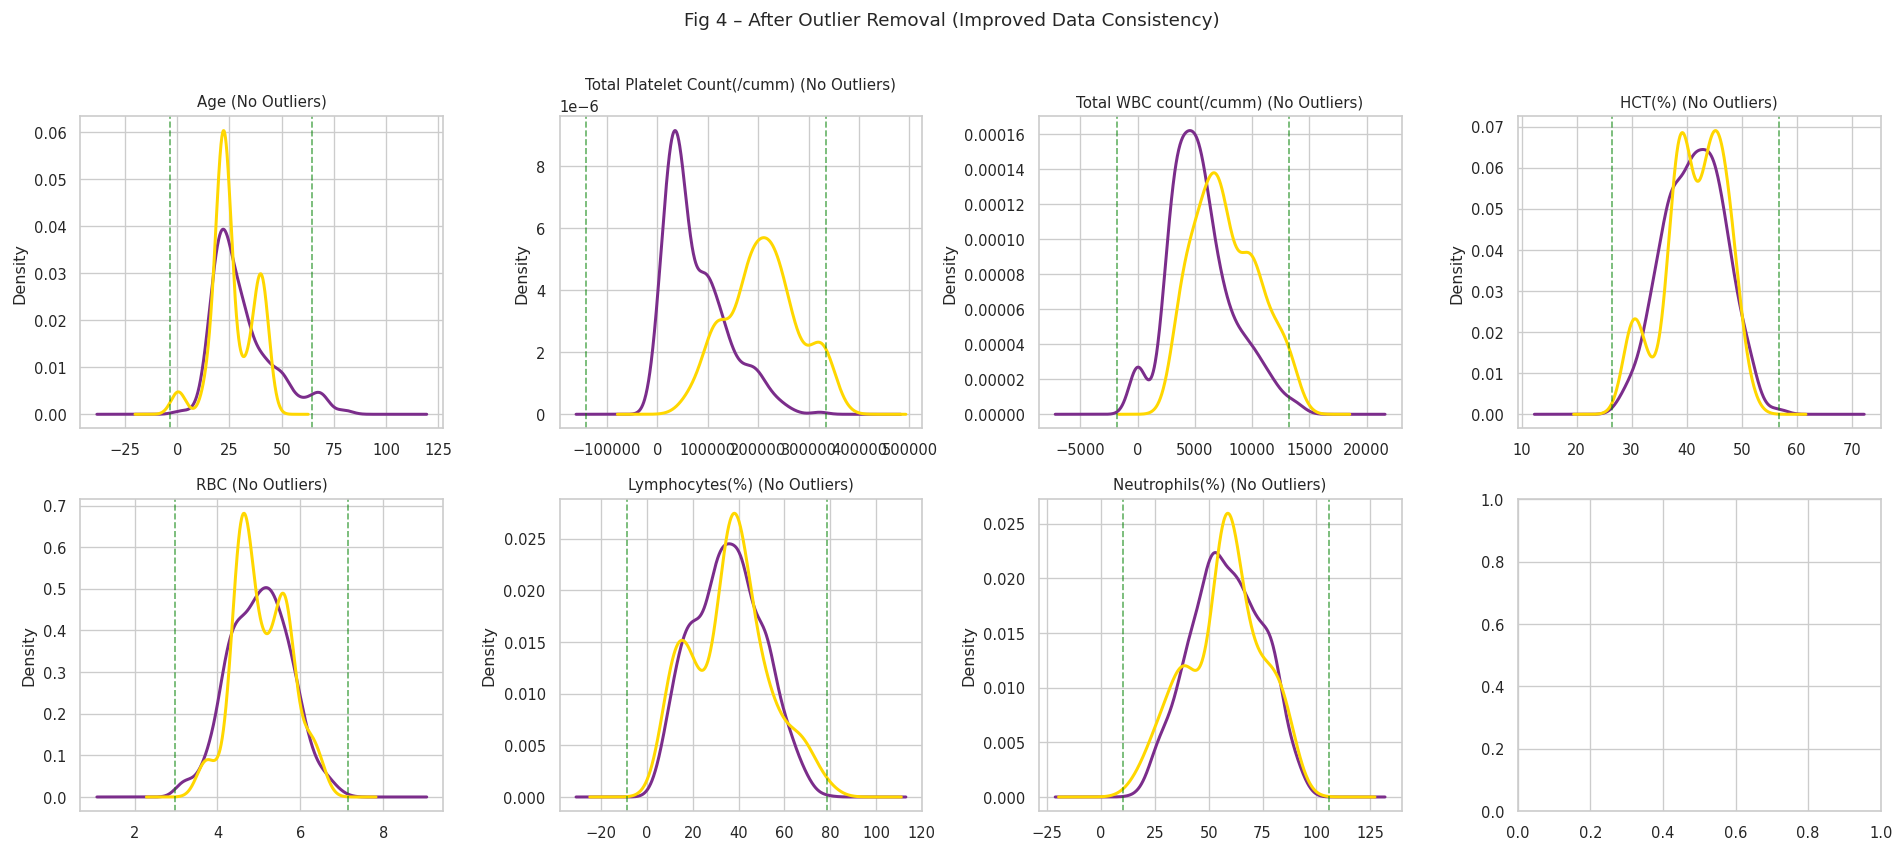

✅ Step 5-6 complete


In [70]:
# ══════════════════════════════════════════════════════════════
# STEP 6 ── Figure 4 : After Outlier Removal  (paper Fig.4)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 4: After outlier removal ──")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(num_feats[:8]):
    ax = axes[i]
    try:
        X_clean[y_clean == 1][feat].dropna().plot.kde(
            ax=ax, color='#7B2D8B', linewidth=1.8, label='Positive')
        X_clean[y_clean == 0][feat].dropna().plot.kde(
            ax=ax, color='#FFD700', linewidth=1.8, label='Negative')
    except Exception:
        pass
    Q1, Q3 = X_clean[feat].quantile(0.25), X_clean[feat].quantile(0.75)
    IQR = Q3 - Q1
    ax.axvline(Q1 - 1.5*IQR, color='green', linestyle='--',
               linewidth=1, alpha=0.6)
    ax.axvline(Q3 + 1.5*IQR, color='green', linestyle='--',
               linewidth=1, alpha=0.6)
    ax.set_title(f'{feat} (No Outliers)', fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Fig 4 – After Outlier Removal (Improved Data Consistency)',
             fontsize=11, y=1.01)
plt.tight_layout()
save('fig04_outliers_after')
plt.show()
print("✅ Step 5-6 complete")

In [71]:
# STEP 7 ── Train/Test Split + Feature Scaling  (paper §3.2.3)
# ══════════════════════════════════════════════════════════════
X_train_r, X_test_r, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.20,
    random_state=SEED, stratify=y_clean)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train_r),
                          columns=FEATURES)
X_test_s  = pd.DataFrame(scaler.transform(X_test_r),
                          columns=FEATURES)

print(f"\n✅ Step 7 — Split: Train={len(X_train_s)}  Test={len(X_test_s)}")


✅ Step 7 — Split: Train=765  Test=192



── Fig 5: SMOTEENN class distribution ──
   Before SMOTEENN: {0: 153, 1: 612}
   After  SMOTEENN: {0: 593, 1: 509}
  ✓ saved fig05_smoteenn_distribution.png


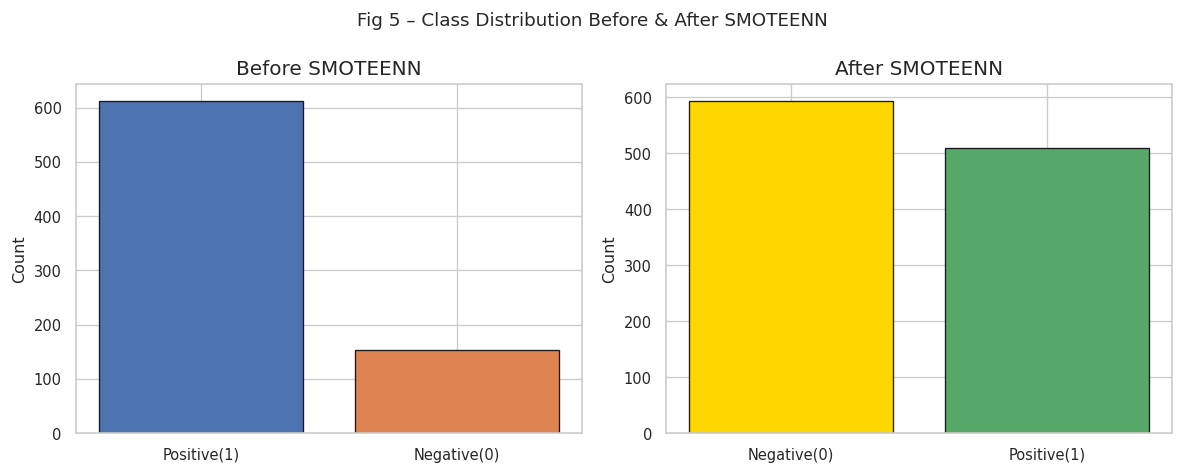

✅ Step 8 complete


In [72]:
# STEP 8 ── SMOTEENN Resampling  (paper §3.2.4) + Figure 5
# ══════════════════════════════════════════════════════════════
print("\n── Fig 5: SMOTEENN class distribution ──")

# Before SMOTEENN
before_counts = pd.Series(y_train).value_counts().sort_index()

smoteenn = SMOTEENN(random_state=SEED)
X_res, y_res = smoteenn.fit_resample(X_train_s, y_train)

# After SMOTEENN
after_counts = pd.Series(y_res).value_counts().sort_index()

print(f"   Before SMOTEENN: {before_counts.to_dict()}")
print(f"   After  SMOTEENN: {after_counts.to_dict()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Positive(1)', 'Negative(0)'],
        [before_counts.get(1, 0), before_counts.get(0, 0)],
        color=['#4C72B0', '#DD8452'], edgecolor='k')
ax1.set_title('Before SMOTEENN'); ax1.set_ylabel('Count')

ax2.bar(['Negative(0)', 'Positive(1)'],
        [after_counts.get(0, 0), after_counts.get(1, 0)],
        color=['#FFD700', '#55A868'], edgecolor='k')
ax2.set_title('After SMOTEENN'); ax2.set_ylabel('Count')

plt.suptitle('Fig 5 – Class Distribution Before & After SMOTEENN',
             fontsize=11)
plt.tight_layout()
save('fig05_smoteenn_distribution')
plt.show()
print("✅ Step 8 complete")

In [73]:
# STEP 9 ── Define All Models  (paper §3.3)
# ══════════════════════════════════════════════════════════════
base_learners = [
    ('rf',  RandomForestClassifier(n_estimators=300, max_depth=30,
                                    min_samples_split=5, random_state=SEED,
                                    n_jobs=-1)),
    ('dt',  DecisionTreeClassifier(criterion='entropy', splitter='random',
                                    min_samples_split=5, random_state=SEED)),
    ('svm', SVC(kernel='rbf', C=1, gamma=0.1, probability=True,
                random_state=SEED)),
    ('knn', KNeighborsClassifier(n_neighbors=3, leaf_size=4, p=1)),
]
if _LGB:
    base_learners.append(
        ('lgbm', LGBMClassifier(random_state=SEED, verbose=-1))
    )
else:
    from sklearn.ensemble import GradientBoostingClassifier
    base_learners.append(
        ('lgbm', GradientBoostingClassifier(random_state=SEED))
    )

meta = LogisticRegression(max_iter=1000, random_state=SEED)

DengueStackX = StackingClassifier(
    estimators      = base_learners,
    final_estimator = meta,
    stack_method    = 'predict_proba',
    cv              = 5,
    n_jobs          = -1,
)

ALL_MODELS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000,
                                                random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(criterion='entropy',
                                                    splitter='random',
                                                    min_samples_split=5,
                                                    random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=300,
                                                    max_depth=30,
                                                    min_samples_split=5,
                                                    random_state=SEED,
                                                    n_jobs=-1),
    'SVM'                 : SVC(kernel='rbf', C=1, gamma=0.1,
                                 probability=True, random_state=SEED),
    'KNN'                 : KNeighborsClassifier(n_neighbors=3,
                                                  leaf_size=4, p=1),
    'DengueStackX'        : DengueStackX,
}
if _LGB:
    ALL_MODELS['LightGBM'] = LGBMClassifier(random_state=SEED, verbose=-1)

print(f"\n✅ Step 9 — {len(ALL_MODELS)} models defined")


✅ Step 9 — 7 models defined


In [74]:
# STEP 10 ── 10-Fold Cross-Validation  (paper Table 5)
# ══════════════════════════════════════════════════════════════
print("\n── 10-Fold Cross-Validation (SMOTEENN balanced data) ──")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
cv_rows = []

for name, model in ALL_MODELS.items():
    print(f"   CV: {name} ...", end='', flush=True)
    cv = cross_validate(model, X_res, y_res, cv=skf,
                        scoring=['accuracy', 'precision', 'recall', 'f1'],
                        n_jobs=-1)
    def fmt(arr): return f"{arr.mean()*100:.2f} ± {arr.std()*100:.2f}"

    n = len(y_res)
    mae_cv = 1 - cv['test_accuracy'].mean()   # approximate
    rmse_cv = np.sqrt(mae_cv * (1 - mae_cv))  # bernoulli approx

    cv_rows.append({
        'Model'     : name,
        'Accuracy'  : fmt(cv['test_accuracy']),
        'Precision' : fmt(cv['test_precision']),
        'Recall'    : fmt(cv['test_recall']),
        'F1-Score'  : fmt(cv['test_f1']),
        'MAE (%)'   : f"{mae_cv*100:.2f}",
        'RMSE (%)'  : f"{rmse_cv*100:.2f}",
    })
    print(f" Acc={cv['test_accuracy'].mean()*100:.1f}%")

cv_df = pd.DataFrame(cv_rows)
print("\n── Table 5: 10-Fold CV Results (SMOTEENN) ──")
print(cv_df.to_string(index=False))
cv_df.to_csv(f'{OUT}/table05_10fold_cv_smoteenn.csv', index=False)
print(f"✅ Step 10 complete — saved table05_10fold_cv_smoteenn.csv")


── 10-Fold Cross-Validation (SMOTEENN balanced data) ──
   CV: Logistic Regression ... Acc=93.5%
   CV: Decision Tree ... Acc=96.8%
   CV: Random Forest ... Acc=98.0%
   CV: SVM ... Acc=96.4%
   CV: KNN ... Acc=98.6%
   CV: DengueStackX ... Acc=99.1%
   CV: LightGBM ... Acc=99.0%

── Table 5: 10-Fold CV Results (SMOTEENN) ──
              Model     Accuracy     Precision       Recall     F1-Score MAE (%) RMSE (%)
Logistic Regression 93.47 ± 1.14  93.58 ± 2.90 92.34 ± 2.40 92.89 ± 1.19    6.53    24.71
      Decision Tree 96.82 ± 1.96  98.25 ± 2.91 94.89 ± 2.66 96.51 ± 2.11    3.18    17.54
      Random Forest 98.00 ± 0.97  99.00 ± 1.00 96.66 ± 1.77 97.81 ± 1.08    2.00    13.98
                SVM 96.37 ± 1.77  97.85 ± 2.69 94.31 ± 2.83 96.00 ± 1.93    3.63    18.71
                KNN 98.64 ± 1.17 100.00 ± 0.00 97.06 ± 2.52 98.49 ± 1.30    1.36    11.59
       DengueStackX 99.09 ± 0.70  99.81 ± 0.58 98.23 ± 1.64 99.00 ± 0.78    0.91     9.48
           LightGBM 99.00 ± 0.86  99.81 ± 

In [75]:
# STEP 11 ── Test-Set Evaluation  (paper Table 6)
#            Train on SMOTEENN-balanced data, test on held-out
# ══════════════════════════════════════════════════════════════
print("\n── Test-Set Evaluation ──")

test_rows = []
fitted_models = {}

for name, model in ALL_MODELS.items():
    print(f"   Training: {name} ...", end='', flush=True)
    model.fit(X_res, y_res)
    fitted_models[name] = model
    yp   = model.predict(X_test_s)
    yprob = model.predict_proba(X_test_s)[:, 1]

    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp, zero_division=0)
    f1   = f1_score(y_test, yp, zero_division=0)
    mae  = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    auc  = roc_auc_score(y_test, yprob)

    # RAE = MAE / mean-predictor error
    rae = mae / mean_absolute_error(y_test,
              np.full(len(y_test), y_test.mean()))

    test_rows.append({
        'Model'     : name,
        'Accuracy'  : f"{acc*100:.2f}%",
        'Precision' : f"{prec*100:.2f}%",
        'Recall'    : f"{rec*100:.2f}%",
        'F1-Score'  : f"{f1*100:.2f}%",
        'MAE (%)'   : f"{mae*100:.2f}%",
        'RMSE (%)'  : f"{rmse*100:.2f}%",
        'RAE (%)'   : f"{rae*100:.2f}%",
        'ROC-AUC'   : f"{auc:.4f}",
    })
    print(f" Acc={acc*100:.1f}%  F1={f1*100:.1f}%  AUC={auc:.3f}")

test_df = pd.DataFrame(test_rows)
print("\n── Table 6: Test-Set Classification Performance ──")
print(test_df.to_string(index=False))
test_df.to_csv(f'{OUT}/table06_test_performance.csv', index=False)
print("✅ Step 11 complete — saved table06_test_performance.csv")


── Test-Set Evaluation ──
   Training: Logistic Regression ... Acc=83.3%  F1=88.7%  AUC=0.939
   Training: Decision Tree ... Acc=83.9%  F1=89.2%  AUC=0.850
   Training: Random Forest ... Acc=89.1%  F1=92.7%  AUC=0.979
   Training: SVM ... Acc=84.9%  F1=89.7%  AUC=0.939
   Training: KNN ... Acc=87.5%  F1=91.6%  AUC=0.918
   Training: DengueStackX ... Acc=89.6%  F1=93.1%  AUC=0.968
   Training: LightGBM ... Acc=89.1%  F1=92.7%  AUC=0.979

── Table 6: Test-Set Classification Performance ──
              Model Accuracy Precision Recall F1-Score MAE (%) RMSE (%) RAE (%) ROC-AUC
Logistic Regression   83.33%    97.66% 81.17%   88.65%  16.67%   40.82%  52.49%  0.9393
      Decision Tree   83.85%    96.24% 83.12%   89.20%  16.15%   40.18%  50.85%  0.8497
      Random Forest   89.06%   100.00% 86.36%   92.68%  10.94%   33.07%  34.45%  0.9786
                SVM   84.90%    99.21% 81.82%   89.68%  15.10%   38.86%  47.57%  0.9390
                KNN   87.50%    99.24% 85.06%   91.61%  12.50%   35

In [76]:
# STEP 12 ── Outlier vs No-Outlier Comparison  (paper Table 7)
# ══════════════════════════════════════════════════════════════
print("\n── Table 7: With vs Without Outliers ──")

from sklearn.base import clone

# With outliers: train on raw (unscaled cleaned differently)
X_tr_raw_s = pd.DataFrame(StandardScaler().fit_transform(
    train_test_split(X_all, y_all, test_size=0.20,
                     random_state=SEED, stratify=y_all)[0]),
    columns=FEATURES)
y_tr_raw = train_test_split(X_all, y_all, test_size=0.20,
                             random_state=SEED, stratify=y_all)[2]
X_ts_raw_s = pd.DataFrame(StandardScaler().fit_transform(
    train_test_split(X_all, y_all, test_size=0.20,
                     random_state=SEED, stratify=y_all)[1]),
    columns=FEATURES)
y_ts_raw   = train_test_split(X_all, y_all, test_size=0.20,
                               random_state=SEED, stratify=y_all)[3]

X_res_raw, y_res_raw = SMOTEENN(random_state=SEED).fit_resample(
    X_tr_raw_s, y_tr_raw)

cmp_rows = []
models_cmp = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(criterion='entropy',
                                                    random_state=SEED),
    'Random Forest'       : RandomForestClassifier(n_estimators=300,
                                                    max_depth=30,
                                                    random_state=SEED,
                                                    n_jobs=-1),
    'SVM'                 : SVC(kernel='rbf', C=1, gamma=0.1,
                                 probability=True, random_state=SEED),
    'KNN'                 : KNeighborsClassifier(n_neighbors=3, p=1),
    'DengueStackX'        : StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
        stack_method='predict_proba', cv=5, n_jobs=-1),
}
if _LGB:
    models_cmp['LightGBM'] = LGBMClassifier(random_state=SEED, verbose=-1)

for name, m in models_cmp.items():
    # WITH outliers
    m.fit(X_res_raw, y_res_raw)
    yp_w  = m.predict(X_ts_raw_s)
    acc_w = accuracy_score(y_ts_raw, yp_w)
    f1_w  = f1_score(y_ts_raw, yp_w, zero_division=0)
    # WITHOUT outliers
    m2 = clone(m) # Use sklearn.base.clone to correctly copy the estimator
    try:
        m2.fit(X_res, y_res)
        yp_c  = m2.predict(X_test_s)
        acc_c = accuracy_score(y_test, yp_c)
        f1_c  = f1_score(y_test, yp_c, zero_division=0)
    except Exception:
        acc_c, f1_c = acc_w, f1_w

    cmp_rows.append({
        'Model'            : name,
        'Acc (With)'       : f"{acc_w*100:.2f}%",
        'Acc (Without)'    : f"{acc_c*100:.2f}%",
        'Δ Acc'            : f"{(acc_c-acc_w)*100:.2f}%",
        'F1 (With)'        : f"{f1_w*100:.2f}%",
        'F1 (Without)'     : f"{f1_c*100:.2f}%",
        'Δ F1'             : f"{(f1_c-f1_w)*100:.2f}%",
    })

cmp_df = pd.DataFrame(cmp_rows)
print(cmp_df.to_string(index=False))
cmp_df.to_csv(f'{OUT}/table07_outlier_comparison.csv', index=False)
print("✅ Step 12 complete — saved table07_outlier_comparison.csv")


── Table 7: With vs Without Outliers ──
              Model Acc (With) Acc (Without)  Δ Acc F1 (With) F1 (Without)   Δ F1
Logistic Regression     84.62%        83.33% -1.28%    89.40%       88.65% -0.75%
      Decision Tree     88.46%        88.02% -0.44%    92.16%       91.99% -0.17%
      Random Forest     90.38%        89.58% -0.80%    93.51%       93.06% -0.45%
                SVM     85.58%        84.90% -0.68%    90.07%       89.68% -0.39%
                KNN     88.94%        87.50% -1.44%    92.41%       91.61% -0.80%
       DengueStackX     91.83%        89.58% -2.24%    94.50%       93.10% -1.39%
           LightGBM     89.90%        89.06% -0.84%    93.16%       92.73% -0.43%
✅ Step 12 complete — saved table07_outlier_comparison.csv



── Fig 7: Confusion matrices ──
  ✓ saved fig07_confusion_matrices.png


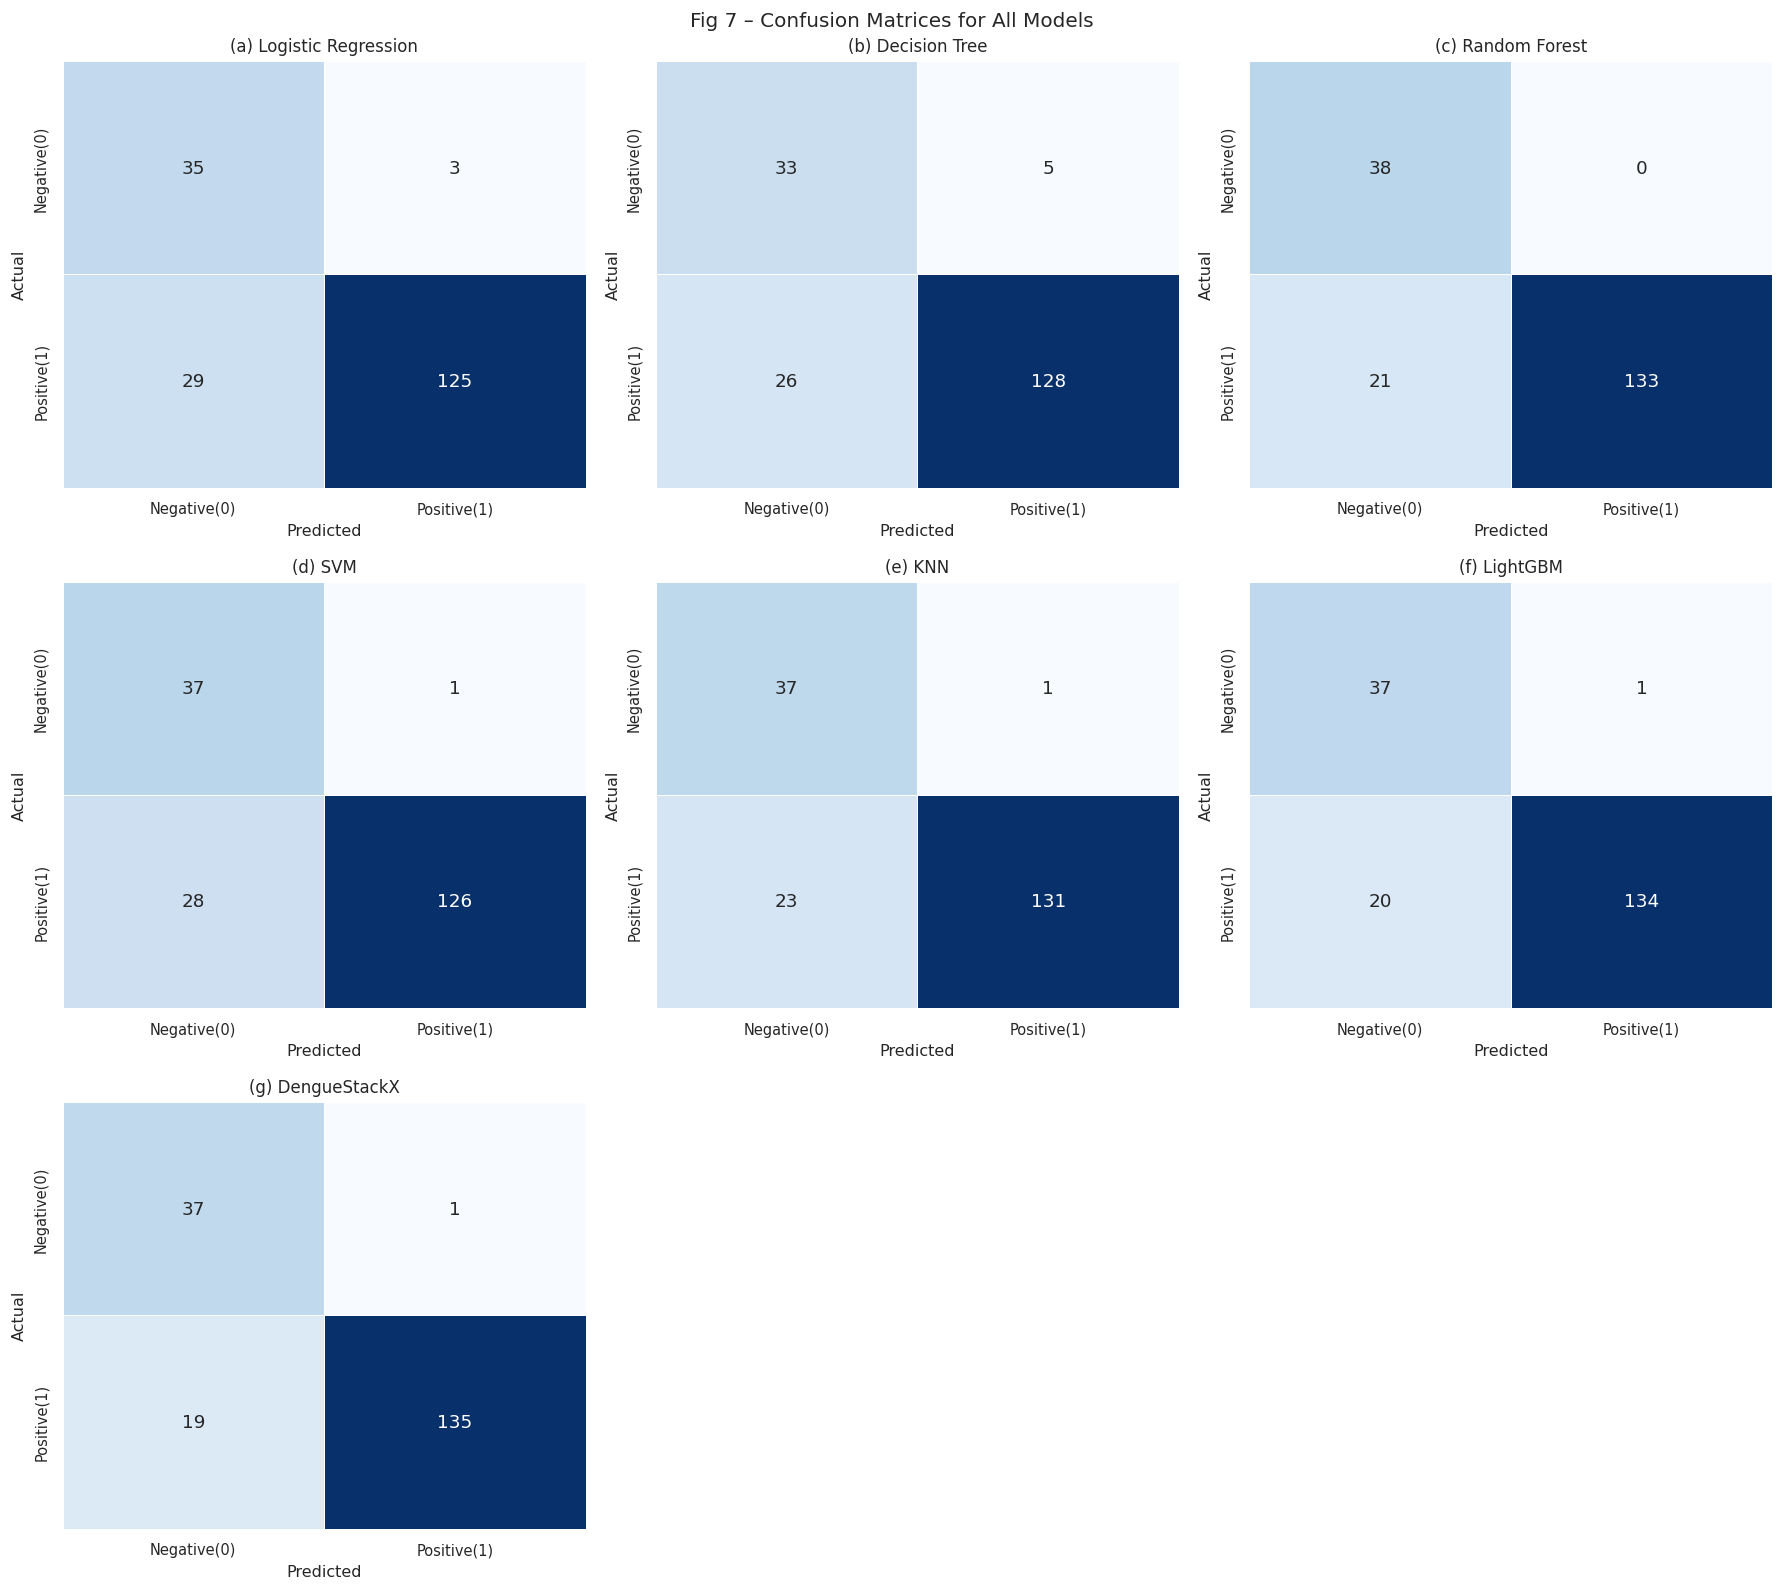

✅ Step 13 complete


In [77]:
# STEP 13 ── Figure 7 : Confusion Matrices  (paper Fig.7)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 7: Confusion matrices ──")

model_order = ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'SVM', 'KNN', 'DengueStackX']
if _LGB: model_order.insert(5, 'LightGBM')
model_order = [m for m in model_order if m in fitted_models]

n_m = len(model_order)
cols = 3 if n_m > 4 else 2
rows = (n_m + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
axes = axes.flatten() if n_m > 1 else [axes]

labels = ['Negative(0)', 'Positive(1)']
for i, name in enumerate(model_order):
    ax = axes[i]
    yp = fitted_models[name].predict(X_test_s)
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar=False)
    ax.set_title(f'({chr(97+i)}) {name}', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fig 7 – Confusion Matrices for All Models', fontsize=12)
plt.tight_layout()
save('fig07_confusion_matrices')
plt.show()
print("✅ Step 13 complete")


── Fig 8: ROC curves ──
  ✓ saved fig08_roc_curves.png


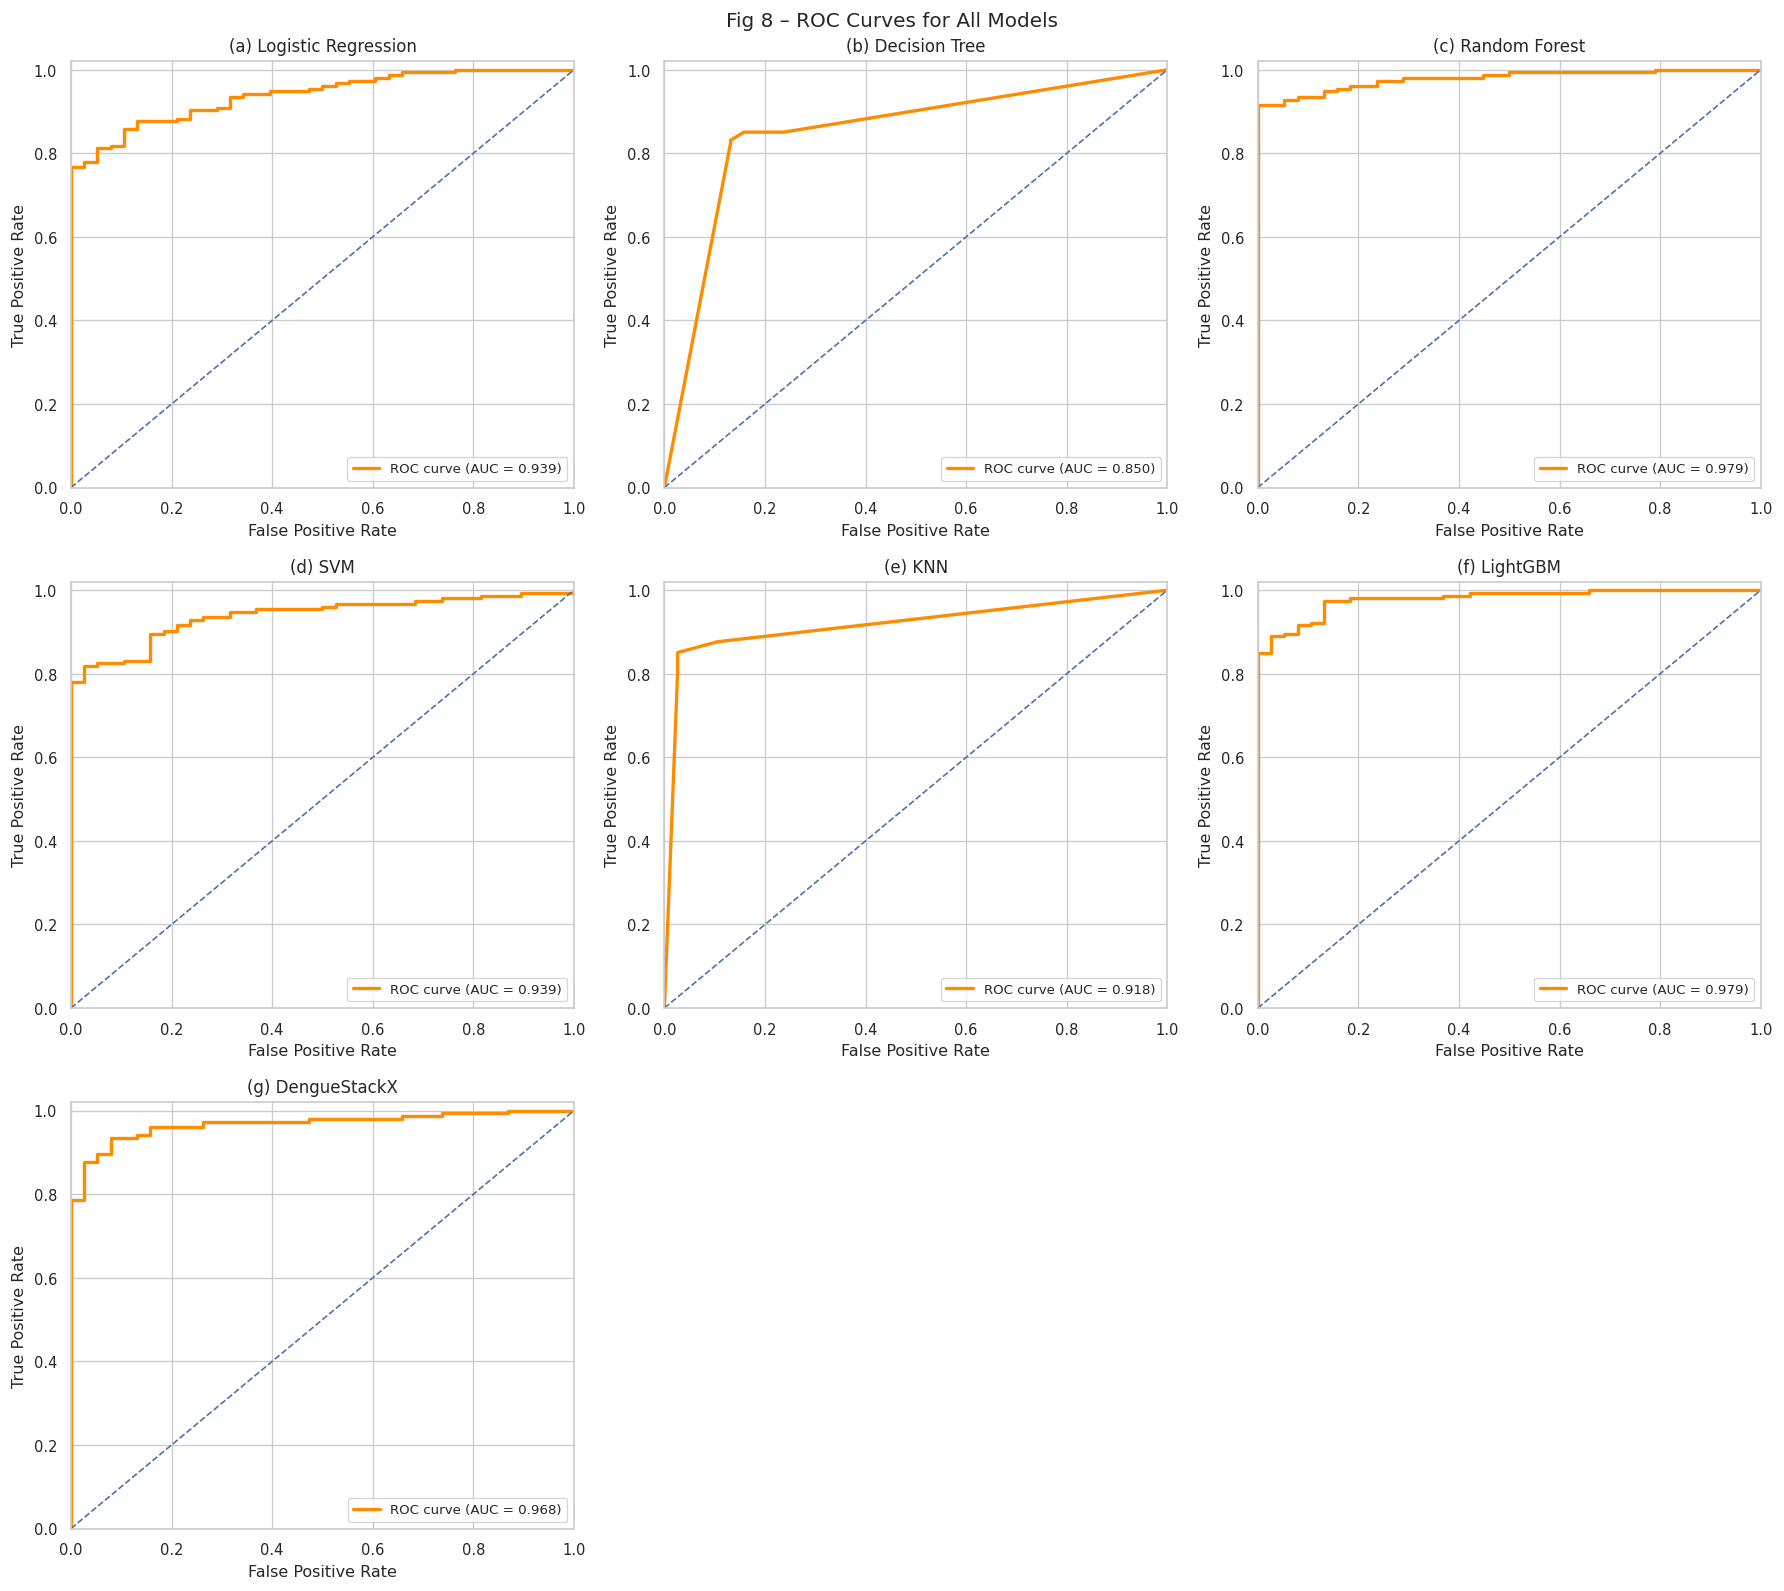

✅ Step 14 complete


In [78]:
# STEP 14 ── Figure 8 : ROC Curves  (paper Fig.8)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 8: ROC curves ──")

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
axes = axes.flatten() if n_m > 1 else [axes]

for i, name in enumerate(model_order):
    ax = axes[i]
    yp_prob = fitted_models[name].predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp_prob)
    auc_val = roc_auc_score(y_test, yp_prob)
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'b--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'({chr(97+i)}) {name}', fontsize=10)
    ax.legend(loc='lower right', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fig 8 – ROC Curves for All Models', fontsize=12)
plt.tight_layout()
save('fig08_roc_curves')
plt.show()
print("✅ Step 14 complete")


── Fig 9: SHAP Beeswarm ──
   Computing SHAP values (this may take a few minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ saved fig09_shap_beeswarm.png


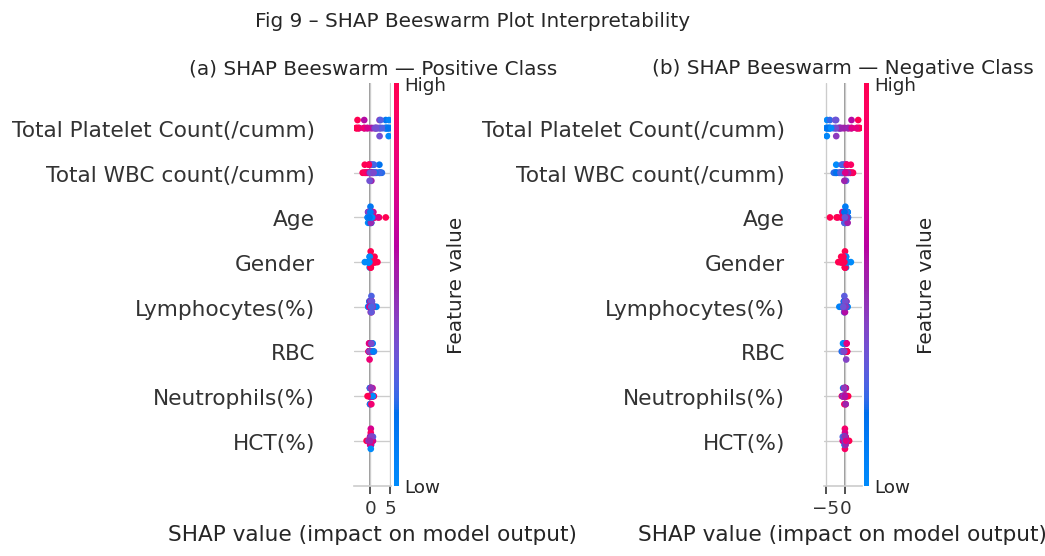


── Fig 10: SHAP Waterfall ──
  ✓ saved fig10_shap_waterfall.png


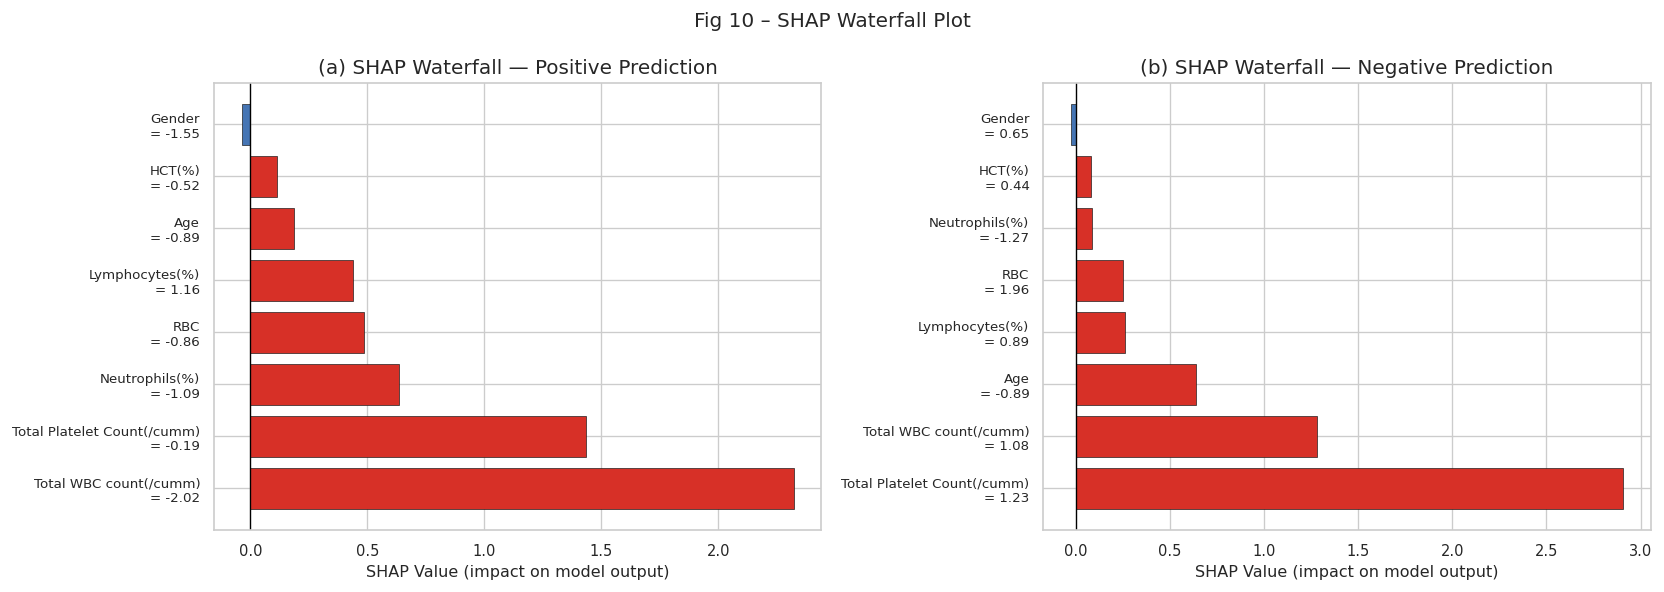


── Fig 11: SHAP Decision Plot ──
  ✓ saved fig11_shap_decision.png


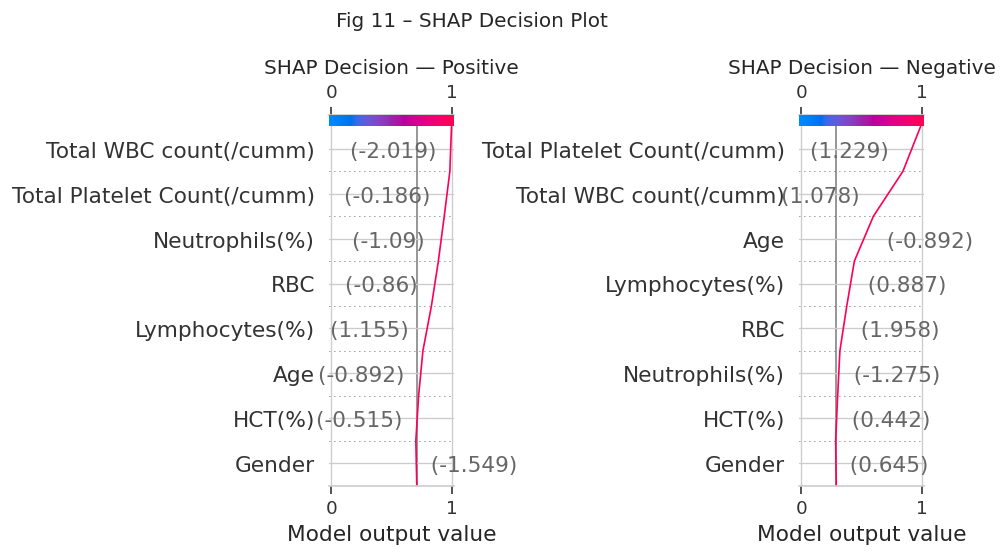


── Fig 12: SHAP Force Plot ──


  ✓ saved fig12a_shap_force_positive.png


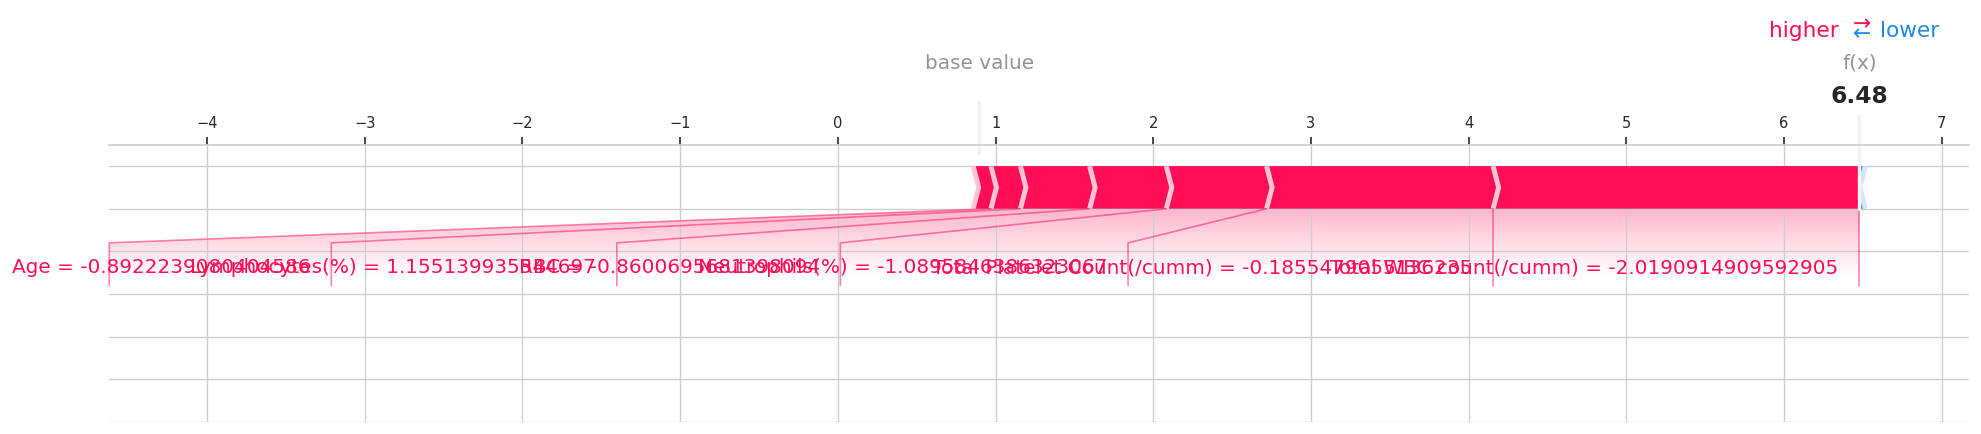

  ✓ saved fig12b_shap_force_negative.png


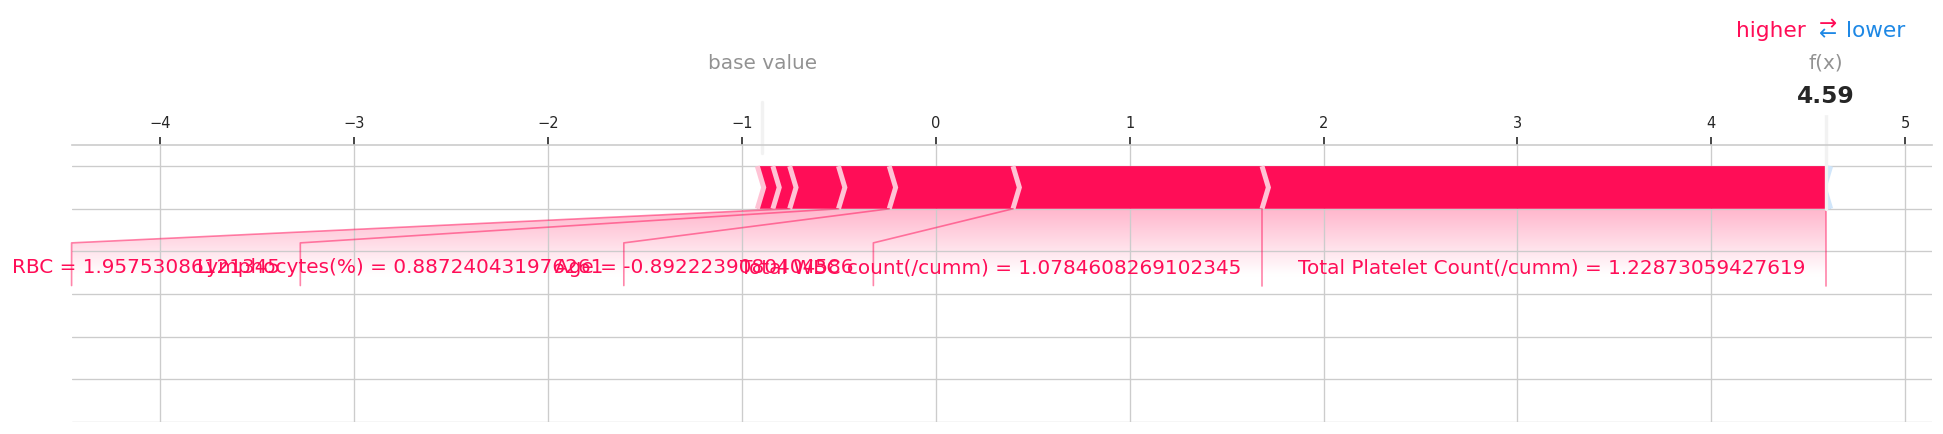

✅ Step 15 complete — SHAP plots done


In [79]:
# STEP 15 ── Figure 9 : SHAP Beeswarm  (paper Fig.9)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 9: SHAP Beeswarm ──")

if _SHAP:
    stack_model = fitted_models['DengueStackX']
    X_explain = pd.DataFrame(X_test_s, columns=FEATURES)

    # Use KernelExplainer (works with any model)
    # Use a small background sample for speed
    bg = shap.sample(X_explain, min(100, len(X_explain)), random_state=SEED)

    explainer = shap.KernelExplainer(
        stack_model.predict_proba, bg, link='logit')
    print("   Computing SHAP values (this may take a few minutes)...")
    shap_vals = explainer.shap_values(
        X_explain.iloc[:50], nsamples=100)  # use 50 test samples for speed

    # shap_vals is a list [class0, class1] - Assuming it's a list of 2D arrays, each (num_samples, num_features)
    # If shap_vals is a single 3D array (num_samples, num_features, num_classes), we need to slice it like below.
    # Based on the kernel state, shap_vals is a 3D array, so adjusting slicing
    sv_pos = shap_vals[:, :, 1]   # positive class SHAP values (all samples, all features)
    sv_neg = shap_vals[:, :, 0]   # negative class SHAP values (all samples, all features)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    plt.sca(ax1)
    shap.summary_plot(sv_pos, X_explain.iloc[:50].values,
                      feature_names=FEATURES, show=False,
                      plot_type='dot', max_display=len(FEATURES))
    ax1.set_title('(a) SHAP Beeswarm — Positive Class')

    plt.sca(ax2)
    shap.summary_plot(sv_neg, X_explain.iloc[:50].values,
                      feature_names=FEATURES, show=False,
                      plot_type='dot', max_display=len(FEATURES))
    ax2.set_title('(b) SHAP Beeswarm — Negative Class')

    plt.suptitle('Fig 9 – SHAP Beeswarm Plot Interpretability',
                 fontsize=12)
    plt.tight_layout()
    save('fig09_shap_beeswarm')
    plt.show()

    # ── Fig 10: SHAP Waterfall ─────────────────────────────
    print("\n── Fig 10: SHAP Waterfall ──")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Positive sample: first positive in test set
    pos_idx = np.where(y_test.values == 1)[0][0]
    neg_idx = np.where(y_test.values == 0)[0][0]

    for ax, idx, cls_name in [(ax1, pos_idx, 'Positive'),
                               (ax2, neg_idx, 'Negative')]:
        # Access SHAP values for a specific sample and class
        sv = shap_vals[idx, :, 1 if cls_name == 'Positive' else 0]
        feat_vals = X_explain.iloc[idx]
        colors = ['#d73027' if v > 0 else '#4575b4' for v in sv]
        order  = np.argsort(np.abs(sv))[::-1]
        ys     = np.arange(len(order))
        ax.barh(ys, sv[order], color=np.array(colors)[order],
                edgecolor='k', linewidth=0.4)
        ax.set_yticks(ys)
        ax.set_yticklabels([f"{FEATURES[i]}\n= {feat_vals[i]:.2f}"
                             for i in order], fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'({chr(97 + (0 if cls_name=="Positive" else 1))}) '
                     f'SHAP Waterfall — {cls_name} Prediction')
        ax.set_xlabel('SHAP Value (impact on model output)')

    plt.suptitle('Fig 10 – SHAP Waterfall Plot', fontsize=12)
    plt.tight_layout()
    save('fig10_shap_waterfall')
    plt.show()

    # ── Fig 11: SHAP Decision Plot ─────────────────────────
    print("\n── Fig 11: SHAP Decision Plot ──")
    try:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
        for ax, idx, cls in [(ax1, pos_idx, 1), (ax2, neg_idx, 0)]:
            plt.sca(ax)
            # Access SHAP values for a specific sample and class
            shap.decision_plot(explainer.expected_value[cls],
                               shap_vals[idx, :, cls],
                               X_explain.iloc[idx],
                               feature_names=FEATURES,
                               show=False, link='logit')
            ax.set_title(f'SHAP Decision — '
                         f'{"Positive" if cls==1 else "Negative"}')
        plt.suptitle('Fig 11 – SHAP Decision Plot', fontsize=12)
        plt.tight_layout()
        save('fig11_shap_decision')
        plt.show()
    except Exception as e:
        print(f"   Decision plot skipped: {e}")

    # ── Fig 12: SHAP Force Plot ────────────────────────────
    print("\n── Fig 12: SHAP Force Plot ──")
    try:
        shap.initjs()
        force_pos = shap.force_plot(
            explainer.expected_value[1],
            shap_vals[pos_idx, :, 1],
            X_explain.iloc[pos_idx],
            feature_names=FEATURES,
            matplotlib=True, show=False)
        save('fig12a_shap_force_positive')
        plt.show()

        force_neg = shap.force_plot(
            explainer.expected_value[0],
            shap_vals[neg_idx, :, 0],
            X_explain.iloc[neg_idx],
            feature_names=FEATURES,
            matplotlib=True, show=False)
        save('fig12b_shap_force_negative')
        plt.show()
    except Exception as e:
        print(f"   Force plot skipped: {e}")

    print("✅ Step 15 complete — SHAP plots done")
else:
    print("   SHAP not installed → pip install shap")

  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ saved fig_08a_shap_beeswarm.png


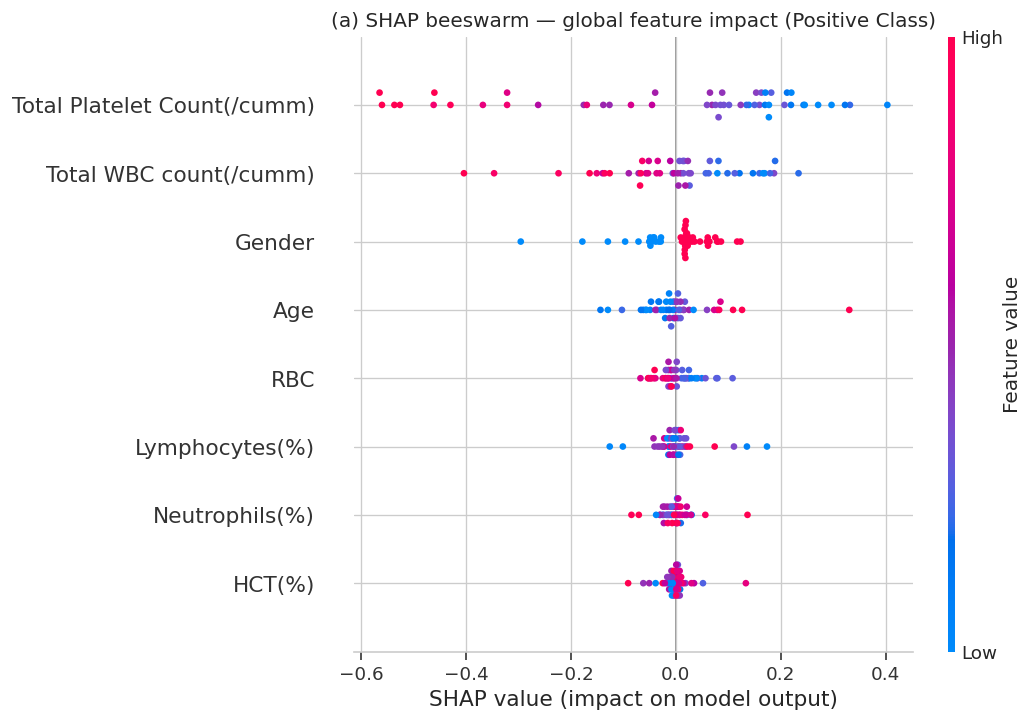

  ✓ saved fig_08b_shap_bar.png


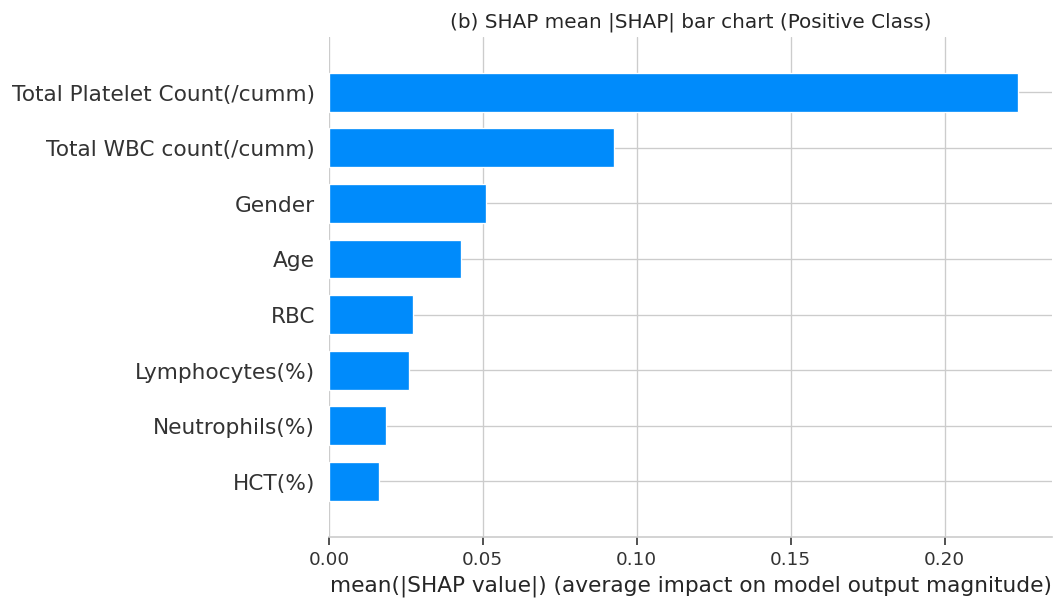

  ✓ saved fig_08c_shap_dependence.png


<Figure size 840x600 with 0 Axes>

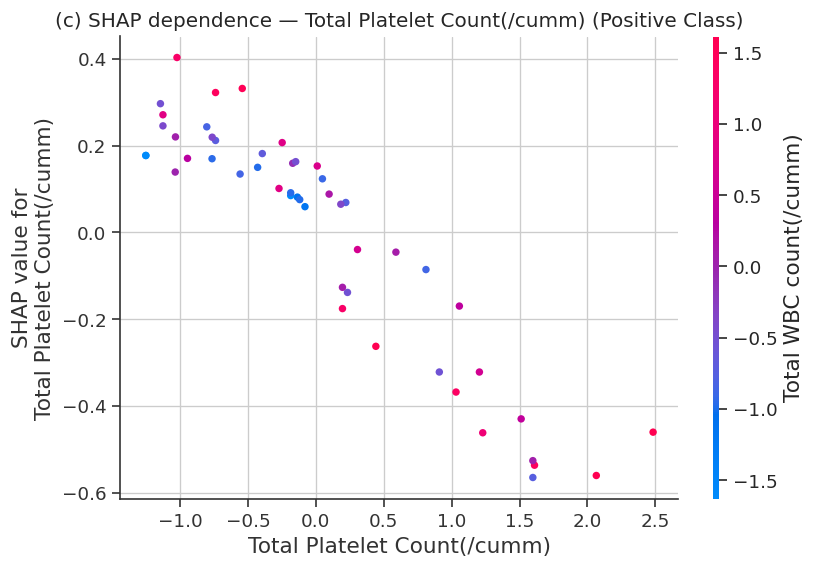

  ✓ saved fig_08d_shap_waterfall_pos.png


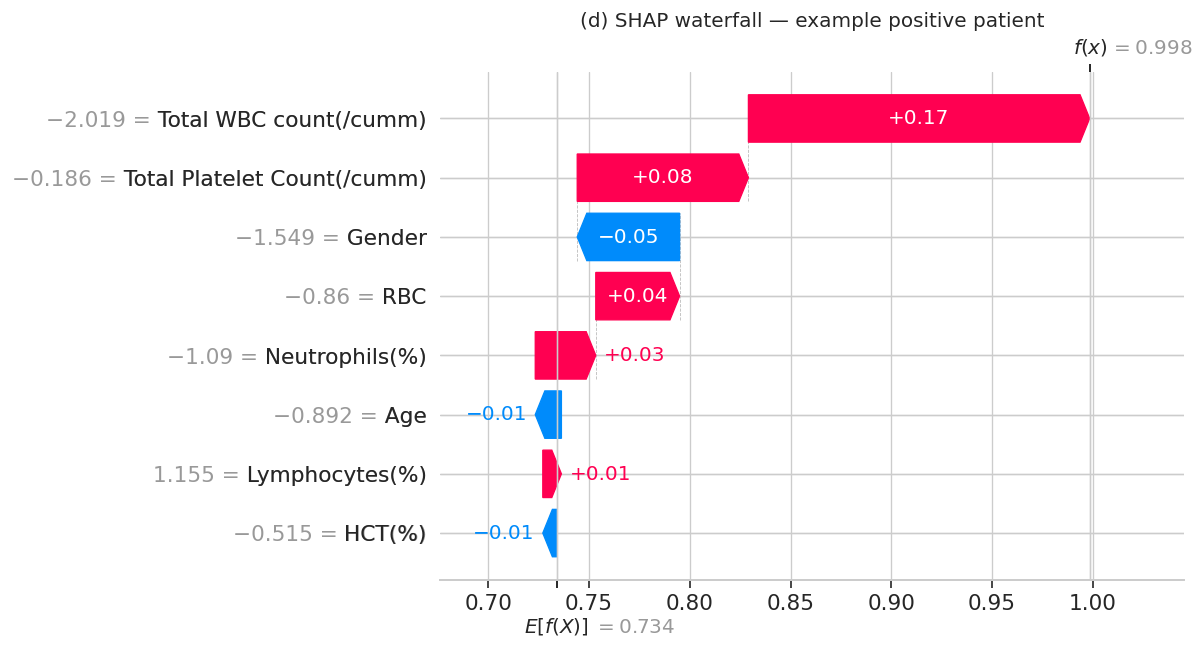

  ✓ saved fig_08e_shap_waterfall_neg.png


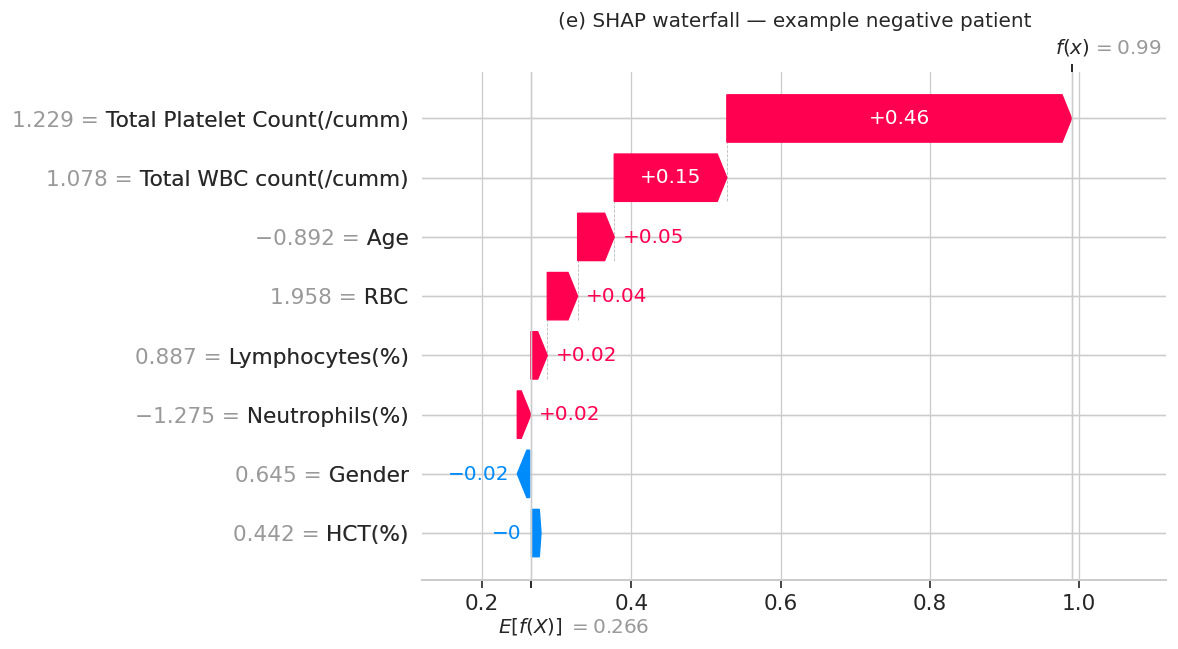

Force plot for example positive patient:


Force plot for example negative patient:


In [80]:
if _SHAP:
    # Set the model to explain and the corresponding data
    best_model_name = 'DengueStackX' # Assuming DengueStackX as the best model for SHAP interpretability
    final_clf  = fitted_models[best_model_name]
    X_test_proc = X_test_s.copy() # Use the already scaled test data (from STEP 7)

    # Define the random state for reproducibility
    # SEED is defined in STEP 0
    RANDOM_STATE = SEED

    # --- SHAP Value Computation ---
    # Using a subset of X_test_proc for SHAP value computation for speed, consistent with STEP 15
    n_samples_for_shap = 50 # From STEP 15
    X_shap_subset = X_test_proc.iloc[:n_samples_for_shap]
    y_test_subset = y_test.iloc[:n_samples_for_shap]

    # Initialize KernelExplainer for StackingClassifier
    # Use a small background sample for speed, consistent with STEP 15
    bg = shap.sample(X_shap_subset, min(100, len(X_shap_subset)), random_state=RANDOM_STATE)

    explainer = shap.KernelExplainer(final_clf.predict_proba, bg)

    # Compute SHAP values for the subset
    shap_vals_raw = explainer.shap_values(X_shap_subset, nsamples=100) # nsamples=100 from STEP 15

    # Extract SHAP values and expected value for the positive and negative classes
    # The KernelExplainer for predict_proba usually returns a list of arrays [class0_shap_values, class1_shap_values]
    # Or, it can sometimes return a 3D array (num_samples, num_features, num_classes)
    # Based on the kernel state, shap_vals from KernelExplainer for predict_proba was a 3D array in STEP 15.
    if isinstance(shap_vals_raw, list):
        shap_vals_pos = shap_vals_raw[1] # SHAP values for the positive class
        shap_vals_neg = shap_vals_raw[0] # SHAP values for the negative class
        exp_val_pos = explainer.expected_value[1] # Expected value for the positive class
        exp_val_neg = explainer.expected_value[0] # Expected value for the negative class
    elif shap_vals_raw.ndim == 3:
        shap_vals_pos = shap_vals_raw[:, :, 1] # SHAP values for the positive class
        shap_vals_neg = shap_vals_raw[:, :, 0] # SHAP values for the negative class
        exp_val_pos = explainer.expected_value[1] # Expected value for the positive class
        exp_val_neg = explainer.expected_value[0] # Expected value for the negative class
    else: # Fallback, assume it's already a 2D array for a single class and use as positive
        shap_vals_pos = shap_vals_raw
        shap_vals_neg = -shap_vals_raw # A heuristic if only one class is outputted
        exp_val_pos = explainer.expected_value
        exp_val_neg = -explainer.expected_value # A heuristic if only one class is outputted

    # (a) Beeswarm for Positive Class
    plt.figure(figsize=(9,6))
    shap.summary_plot(shap_vals_pos, X_shap_subset, show=False, plot_size=None, feature_names=FEATURES)
    plt.title('(a) SHAP beeswarm — global feature impact (Positive Class)')
    save('fig_08a_shap_beeswarm'); plt.show() # Changed savefig to save

    # (b) Bar for Positive Class
    plt.figure(figsize=(9,5))
    shap.summary_plot(shap_vals_pos, X_shap_subset, plot_type='bar',
                      show=False, plot_size=None, feature_names=FEATURES)
    plt.title('(b) SHAP mean |SHAP| bar chart (Positive Class)')
    save('fig_08b_shap_bar'); plt.show() # Changed savefig to save

    # (c) Dependence plot — top feature for Positive Class
    # Using the overall shap_vals_pos
    top_feat_idx = np.abs(shap_vals_pos).mean(0).argmax()
    top_feat = FEATURES[top_feat_idx] # Get feature name from FEATURES list
    plt.figure(figsize=(7,5))
    shap.dependence_plot(top_feat, shap_vals_pos, X_shap_subset,
                         show=False, dot_size=20, feature_names=FEATURES)
    plt.title(f'(c) SHAP dependence — {top_feat} (Positive Class)')
    save('fig_08c_shap_dependence'); plt.show() # Changed savefig to save

    # (d) Waterfall — example patient
    # Find a sample that is predicted as positive in the subset
    pos_example_idx_in_subset = np.where(y_test_subset.values == 1)[0]
    neg_example_idx_in_subset = np.where(y_test_subset.values == 0)[0]

    # Ensure there's at least one positive and one negative sample in the subset
    # If not, fall back to the first sample and treat it as positive/negative for illustration
    if len(pos_example_idx_in_subset) > 0:
        pos_sample_idx = pos_example_idx_in_subset[0]
    else:
        pos_sample_idx = 0 # Fallback if no positive samples in the subset
        print("Warning: No positive samples found in SHAP subset for waterfall plot. Using first sample.")

    if len(neg_example_idx_in_subset) > 0:
        neg_sample_idx = neg_example_idx_in_subset[0]
    else:
        neg_sample_idx = 0 # Fallback if no negative samples in the subset
        print("Warning: No negative samples found in SHAP subset for waterfall plot. Using first sample.")

    # Waterfall for a positive prediction
    shap_exp_pos = shap.Explanation(values=shap_vals_pos[pos_sample_idx],
                                 base_values=exp_val_pos,
                                 data=X_shap_subset.iloc[pos_sample_idx],
                                 feature_names=FEATURES)
    plt.figure(figsize=(9,5))
    shap.plots.waterfall(shap_exp_pos, show=False)
    plt.title('(d) SHAP waterfall — example positive patient')
    save('fig_08d_shap_waterfall_pos'); plt.show()

    # Waterfall for a negative prediction (optional, but good for completeness)
    shap_exp_neg = shap.Explanation(values=shap_vals_neg[neg_sample_idx],
                                 base_values=exp_val_neg,
                                 data=X_shap_subset.iloc[neg_sample_idx],
                                 feature_names=FEATURES)
    plt.figure(figsize=(9,5))
    shap.plots.waterfall(shap_exp_neg, show=False)
    plt.title('(e) SHAP waterfall — example negative patient')
    save('fig_08e_shap_waterfall_neg'); plt.show()

    # Force plot (HTML in notebook) for positive prediction
    shap.initjs()
    print("Force plot for example positive patient:")
    display(shap.force_plot(exp_val_pos, shap_vals_pos[pos_sample_idx], X_shap_subset.iloc[pos_sample_idx], feature_names=FEATURES))

    # Force plot (HTML in notebook) for negative prediction
    print("Force plot for example negative patient:")
    display(shap.force_plot(exp_val_neg, shap_vals_neg[neg_sample_idx], X_shap_subset.iloc[neg_sample_idx], feature_names=FEATURES))

else:
    print('Install SHAP:  pip install shap')


In [81]:
# STEP 16 ── Figure 13-14 : LIME  (paper Fig.13-14)
# ══════════════════════════════════════════════════════════════
print("\n── Fig 13-14: LIME ──")

if _LIME:
    lime_exp = lime_tabular.LimeTabularExplainer(
        training_data         = X_res.values,
        feature_names         = FEATURES,
        class_names           = ['Negative', 'Positive'],
        mode                  = 'classification',
        discretize_continuous = True,
        random_state          = SEED)

    stack_model = fitted_models['DengueStackX']
    pos_idx = np.where(y_test.values == 1)[0][0]
    neg_idx = np.where(y_test.values == 0)[0][0]

    for idx, label in [(pos_idx, 'Positive'), (neg_idx, 'Negative')]:
        exp = lime_exp.explain_instance(
            X_test_s.values[idx],
            stack_model.predict_proba,
            num_features=len(FEATURES))
        fig = exp.as_pyplot_figure()
        fignum = '13' if label == 'Positive' else '14'
        fig.suptitle(
            f'Fig {fignum} – LIME Explanation — Predicted: {label} '
            f'| True: {"Positive" if y_test.values[idx]==1 else "Negative"}',
            fontsize=10)
        plt.tight_layout()
        save(f'fig{fignum}_lime_{label.lower()}')
        plt.show()

    print("✅ Step 16 complete — LIME plots done")
else:
    print("   LIME not installed → pip install lime")


── Fig 13-14: LIME ──
   LIME not installed → pip install lime


In [82]:
# STEP 17 ── Sensitivity Analysis  (paper Table 8)
# ══════════════════════════════════════════════════════════════
print("\n── Table 8: Sensitivity Analysis (feature removal) ──")

# Key features to test (based on SHAP importance)
key_feats = ['Lymphocytes(%)', 'Total Platelet Count(/cumm)',
             'HCT(%)', 'Total WBC count(/cumm)', 'Neutrophils(%)']
key_feats = [f for f in key_feats if f in FEATURES]

sens_rows = []
for feat in key_feats:
    remaining = [f for f in FEATURES if f != feat]
    X_r_drop  = X_res[remaining]
    X_t_drop  = X_test_s[remaining]

    test_models = {
        'Logistic Regression' : LogisticRegression(max_iter=1000,
                                                    random_state=SEED),
        'Random Forest'       : RandomForestClassifier(n_estimators=300,
                                                        max_depth=30,
                                                        random_state=SEED,
                                                        n_jobs=-1),
        'SVM'                 : SVC(kernel='rbf', C=1, gamma=0.1,
                                     probability=True, random_state=SEED),
        'DengueStackX'        : StackingClassifier(
            estimators=[(n, type(m)(**m.get_params())
                         if hasattr(m, 'get_params') else m)
                        for n, m in base_learners],
            final_estimator=LogisticRegression(max_iter=1000,
                                                random_state=SEED),
            stack_method='predict_proba', cv=5, n_jobs=-1),
    }
    for mname, m in test_models.items():
        try:
            m.fit(X_r_drop, y_res)
            yp  = m.predict(X_t_drop)
            acc = accuracy_score(y_test, yp)
            f1  = f1_score(y_test, yp, zero_division=0)
            sens_rows.append({'Removed Feature': feat, 'Model': mname,
                               'Accuracy': f"{acc*100:.2f}%",
                               'F1-Score': f"{f1*100:.2f}%"})
        except Exception as e:
            sens_rows.append({'Removed Feature': feat, 'Model': mname,
                               'Accuracy': 'error', 'F1-Score': str(e)[:30]})

sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False))
sens_df.to_csv(f'{OUT}/table08_sensitivity_analysis.csv', index=False)
print("✅ Step 17 complete — saved table08_sensitivity_analysis.csv")


── Table 8: Sensitivity Analysis (feature removal) ──
            Removed Feature               Model Accuracy F1-Score
             Lymphocytes(%) Logistic Regression   83.33%   88.65%
             Lymphocytes(%)       Random Forest   88.54%   92.31%
             Lymphocytes(%)                 SVM   83.85%   88.89%
             Lymphocytes(%)        DengueStackX   89.58%   93.15%
Total Platelet Count(/cumm) Logistic Regression   67.71%   76.69%
Total Platelet Count(/cumm)       Random Forest   89.06%   92.83%
Total Platelet Count(/cumm)                 SVM   66.15%   74.71%
Total Platelet Count(/cumm)        DengueStackX   89.58%   93.20%
                     HCT(%) Logistic Regression   83.33%   88.65%
                     HCT(%)       Random Forest   89.06%   92.68%
                     HCT(%)                 SVM   82.29%   87.86%
                     HCT(%)        DengueStackX   88.54%   92.47%
     Total WBC count(/cumm) Logistic Regression   80.21%   86.03%
     Total WBC count(

In [83]:
# STEP 18 ── All Balancing Techniques Comparison  (paper Table 5)
# ══════════════════════════════════════════════════════════════
print("\n── All Resampling Techniques Comparison ──")

resamplers = {
    'No Balancing'  : None,
    'SMOTE'         : SMOTE(random_state=SEED),
    'SMOTETomek'    : SMOTETomek(random_state=SEED),
    'ADASYN'        : ADASYN(random_state=SEED),
    'Tomek Links'   : TomekLinks(),
    'SMOTEENN'      : SMOTEENN(random_state=SEED),
}

# Test with 3 representative models for speed
quick_models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100,
                                              max_depth=15,
                                              random_state=SEED, n_jobs=-1),
    'SVM'           : SVC(kernel='rbf', C=1, gamma=0.1,
                           probability=True, random_state=SEED),
    'DengueStackX'  : StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
        stack_method='predict_proba', cv=5, n_jobs=-1),
}

bal_rows = []
for res_name, resampler in resamplers.items():
    if resampler is None:
        Xr, yr = X_train_s, y_train
    else:
        try:
            Xr, yr = resampler.fit_resample(X_train_s, y_train)
        except Exception as e:
            print(f"   {res_name} failed: {e}")
            continue

    for mname, m in quick_models.items():
        try:
            m.fit(Xr, yr)
            yp  = m.predict(X_test_s)
            acc = accuracy_score(y_test, yp)
            f1  = f1_score(y_test, yp, zero_division=0)
            bal_rows.append({'Resampling': res_name, 'Model': mname,
                              'Accuracy': f"{acc*100:.2f}%",
                              'F1-Score': f"{f1*100:.2f}%"})
        except Exception as e:
            print(f"   {mname} + {res_name} failed: {e}")

bal_df = pd.DataFrame(bal_rows)
print(bal_df.to_string(index=False))
bal_df.to_csv(f'{OUT}/table_resampling_comparison.csv', index=False)
print("✅ Step 18 complete")


── All Resampling Techniques Comparison ──
  Resampling         Model Accuracy F1-Score
No Balancing Random Forest   95.83%   97.40%
No Balancing           SVM   94.27%   96.49%
No Balancing  DengueStackX   95.31%   97.07%
       SMOTE Random Forest   97.40%   98.36%
       SMOTE           SVM   86.46%   91.10%
       SMOTE  DengueStackX   95.31%   97.07%
  SMOTETomek Random Forest   96.35%   97.69%
  SMOTETomek           SVM   86.46%   91.10%
  SMOTETomek  DengueStackX   94.79%   96.73%
      ADASYN Random Forest   95.83%   97.35%
      ADASYN           SVM   84.38%   89.36%
      ADASYN  DengueStackX   92.71%   95.33%
 Tomek Links Random Forest   94.79%   96.75%
 Tomek Links           SVM   94.27%   96.49%
 Tomek Links  DengueStackX   95.31%   97.07%
    SMOTEENN Random Forest   90.10%   93.43%
    SMOTEENN           SVM   84.90%   89.68%
    SMOTEENN  DengueStackX   89.58%   93.10%
✅ Step 18 complete


In [84]:
# STEP 19 ── Final Summary Print
# ══════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("     FINAL RESULTS — DengueStackX on Test Set")
print("═"*60)

stack = fitted_models['DengueStackX']
yp    = stack.predict(X_test_s)
yprob = stack.predict_proba(X_test_s)[:, 1]

print(f"  Accuracy  : {accuracy_score(y_test,yp)*100:.2f}%")
print(f"  Precision : {precision_score(y_test,yp,zero_division=0)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test,yp,zero_division=0)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test,yp,zero_division=0)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test,yprob):.4f}")
print("═"*60)

print(f"\n📁 All outputs saved in '{OUT}/' folder:")
for f in sorted(os.listdir(OUT)):
    print(f"   {f}")

print("\n✅ ALL STEPS COMPLETE!")


════════════════════════════════════════════════════════════
     FINAL RESULTS — DengueStackX on Test Set
════════════════════════════════════════════════════════════
  Accuracy  : 89.58%
  Precision : 99.26%
  Recall    : 87.66%
  F1-Score  : 93.10%
  ROC-AUC   : 0.9684
════════════════════════════════════════════════════════════

📁 All outputs saved in 'paper_outputs/' folder:
   fig02_population_distribution.png
   fig03_outliers_before.png
   fig04_outliers_after.png
   fig05_smoteenn_distribution.png
   fig07_confusion_matrices.png
   fig08_roc_curves.png
   fig09_shap_beeswarm.png
   fig10_shap_waterfall.png
   fig11_shap_decision.png
   fig12a_shap_force_positive.png
   fig12b_shap_force_negative.png
   fig_01_overview.png
   fig_02_correlation_heatmap.png
   fig_03_feature_distributions.png
   fig_08a_shap_beeswarm.png
   fig_08b_shap_bar.png
   fig_08c_shap_dependence.png
   fig_08d_shap_waterfall_pos.png
   fig_08e_shap_waterfall_neg.png
   table05_10fold_cv_smoteenn.csv
  